In [1]:
"Doing the Set Up for the Health Analysis project "
"Problem statment: Diebetic Readmission of Patients"
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Utility libraries
import warnings
import os
from datetime import datetime

# Configuration settings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.max_rows', 100)  # Display up to 100 rows
plt.style.use('seaborn-v0_8-darkgrid')  # Set consistent plot style

# Set random seed for reproducibility
np.random.seed(42)


# DATA ACQUISITION FOR DATA ANALYSIS PROJECTS


In [3]:

"""
When working on data analysis projects, the first step is always acquiring
the data. There are multiple ways to get your data, and it's best practice
to implement all of them so your notebook works in different environments.

In this section, we'll cover THREE main approaches to data acquisition:

METHOD 1: Check if Data Already Exists Locally

-----------------------------------------------
'IF YOU ARE WORKING ON COLAB IT WILL ONLY SEE THE GOOGLE DRIVE DIRECTORIES NOT YOU LOCAL MAC BOOK ONES SO "
-----------------------------------------------

Before downloading anything, we should always check if the data already
exists on our local machine. This saves time and bandwidth, especially
when working with large datasets.

Why this matters:
- Prevents unnecessary re-downloads
- Saves time during development (you'll run cells multiple times)
- Good practice for production environments
- Respects data source bandwidth limits

How it works:
- We use Python's 'os' module to check if a file/folder exists
- If found, we load it directly
- If not found, we move to the download methods


METHOD 2: Automatic Download from Direct URL
---------------------------------------------
If the data doesn't exist locally, we automatically try to download it
from a direct URL (like from UCI Machine Learning Repository, Kaggle,
government databases, etc.).

Why this matters:
- Makes your notebook reproducible - anyone can run it
- No manual download steps required
- Can be automated in production pipelines

How it works:
- We use 'requests' library to download files from URLs
- Handle zip files automatically (extract after download)
- Show download progress for large files
- Include error handling for failed downloads


METHOD 3: Google Drive Integration (For Colab/Large Files)
-----------------------------------------------------------
Sometimes data is stored on Google Drive, especially when:
- Working in Google Colab
- Dataset is too large for GitHub
- Sharing private datasets within a team
- Data changes frequently and needs central storage

Why this matters:
- Google Colab doesn't have persistent storage
- Easy way to share datasets with collaborators
- Good for datasets >100MB (GitHub has size limits)

How it works:
TWO OPTIONS for Google Drive:

Option A - Mount Google Drive (Best for Colab):
- Connects your entire Google Drive to the notebook
- Access any file in your Drive as if it's local
- Requires authentication (one-time per session)
- Data stays in Drive, just accessed remotely

Option B - Direct Download from Shared Link:
- Download specific file from a shared Google Drive link
- No authentication needed if file is publicly shared
- Uses 'gdown' library
- File is downloaded to local environment


RECOMMENDED WORKFLOW:
--------------------
1. Try loading from local first (fastest)
2. If not found, try Google Drive (good for Colab)
3. If not available, download from URL (works anywhere)
4. If all fail, show error with manual download instructions

This multi-source approach makes your notebook work in:
- Local Jupyter environments
- Google Colab
- Production servers
- Team member's machines (without manual setup)

"""


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




> Add blockquote


IMPLEMENTATION EXAMPLES BELOW


In [4]:
# ----------------------------------------------------------------------------
# METHOD 3: Google Drive Integration
#AS we are working on Colab so we will just mount the drive and load teh file which i uploaded on drive manually
# ----------------------------------------------------------------------------

data_file = "/content/drive/MyDrive/diabetic_data.csv"
if os.path.exists(data_file):
  print("File Exists in the current directory")
else:
  print("File Doesnot exists")


File Exists in the current directory


In [5]:
#LOADING THE FILE
df_raw = pd.read_csv(data_file)
print("Showing teh first five rows")
df_raw.head()


Showing teh first five rows


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
print ("shoping the shape")
df_raw.shape

shoping the shape


(101766, 50)

In [7]:
print("showing the info")
print(df_raw.info())

showing the info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null 

In [8]:
print("shoing teh statistics")
df_raw.describe()


shoing teh statistics


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [9]:

"We will check for"
# 1) MISSING VALUES
# 2) Duplicate Rows
# 3) Data Types
# 4) Value Distribution
# 5) Outliers


"Making a copy so we dont change the original data file "
df = df_raw.copy()




#Duplicates checking and removing

# 2. How duplicated() works:
# df.duplicated() scans every row and returns a True/False Series:
# Row 0:  False   ← unique
# Row 1:  False   ← unique
# Row 2:  True    ← exact copy of a previous row
# Row 3:  False   ← unique
# Row 4:  True    ← exact copy of a previous row
# Then .sum() counts all the True values — because in Python True = 1 and False = 0.
# So df.duplicated().sum() = total number of duplicate rows.

# Why only .sum() and not rows & columns?
# duplicated() checks the entire row (all columns together). It asks:

# "Does this entire row already exist somewhere above it?"

# It does not check columns individually. One number is enough because it tells you how many full rows are repeated.

# Example:
# pythondf.duplicated().sum()     # → 2  (means 2 rows are exact duplicates)
# df[df.duplicated()]       # shows you WHICH rows are duplicates
# df.drop_duplicates()      # removes them


duplicates = df_raw.duplicated().sum() # sum makes return wcount of rows which are duplicte
print(duplicates)
if duplicates > 0 :
  print(f"percentage of duplicates : {duplicates/len(df_raw)*100}")
else:
  print("No Duplicates")

# we are keeping the duplicate bcs duplicates represent the maybe two tumes visit of teh patient to the hospital i.2 two times encounter
# we will retain them for now and investigate further


0
No Duplicates


# DATA QUALITY ASSESSEMNET


In [10]:
#Missing Values Checking and removing
# print("Number of Rows of the data")
"print(len(df))"
# print("Columns with in the Data")
" print(df.columns)"

# Print("Number of Miasing rows per column")
"print(df.isnull().sum())"
# #again .sum() will give teh count of missing columsn
"what you get"
"-----------------------------------------------------------------------------------"
"df.isnull() entire answer sheet marked ✓ and ✗df.isnull().sum()score per subject"
"-----------------------------------------------------------------------------------"
# print(f"percentage of missing rows per column: {df.isnull().sum() / len(df) * 100}")

"so we are creating a table of missing values "


missing_values_table= pd.DataFrame({
    "Columns" :df_raw.columns,
    "missing Count": df_raw.isnull().sum(),
    "percentage": df_raw.isnull().sum()/len(df)*100
})
print(missing_values_table)
missing_values_table = missing_values_table[missing_values_table['missing Count'] > 0 ].sort_values(by='percentage',ascending=False)
print(missing_values_table)

if len(missing_values_table) > 0:
  print(f"There are {len(missing_values_table)} columns with missing values")
else:
  print("No missing values")

#key take : the higher th emissing rate the greater the chance that we wont use that column in our analysis

                                           Columns  missing Count  percentage
encounter_id                          encounter_id              0    0.000000
patient_nbr                            patient_nbr              0    0.000000
race                                          race              0    0.000000
gender                                      gender              0    0.000000
age                                            age              0    0.000000
weight                                      weight              0    0.000000
admission_type_id                admission_type_id              0    0.000000
discharge_disposition_id  discharge_disposition_id              0    0.000000
admission_source_id            admission_source_id              0    0.000000
time_in_hospital                  time_in_hospital              0    0.000000
payer_code                              payer_code              0    0.000000
medical_specialty                medical_specialty              

In [11]:
#check for the place holders

#health care systems often use 'unknow' or '?' as place holders so we will check for that
placeholder_count = {}
for col in df_raw.columns:
  if df_raw[col].dtype == 'object':
    count = (df_raw[col] == '?').sum()
    if count > 0:
       placeholder_count[col] = {
        'count': count,
        'percentage': count / len(df_raw) * 100
    }
print(placeholder_count)

if placeholder_count:
  print(f"Number of place holder column are {len(placeholder_count)}")
else:
  print("No place holder columns")

#key take if the percentage of place holder is very large we wont include it in our analysis

{'race': {'count': np.int64(2273), 'percentage': np.float64(2.2335554114340743)}, 'weight': {'count': np.int64(98569), 'percentage': np.float64(96.85847925633315)}, 'payer_code': {'count': np.int64(40256), 'percentage': np.float64(39.5574160328597)}, 'medical_specialty': {'count': np.int64(49949), 'percentage': np.float64(49.08220820313268)}, 'diag_1': {'count': np.int64(21), 'percentage': np.float64(0.02063557573256294)}, 'diag_2': {'count': np.int64(358), 'percentage': np.float64(0.3517874339170253)}, 'diag_3': {'count': np.int64(1423), 'percentage': np.float64(1.398305917497003)}}
Number of place holder column are 7


In [12]:
#Find the data types
print(df_raw.dtypes)
for dtypes in df_raw.dtypes.unique():
  cols = df_raw.select_dtypes(include=[dtypes]).columns.tolist()
  print(f"\n{dtypes}:")
  print(f"\n{len(cols)}")



encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

our problem statement is to find the diabetic people who are readmitted 
so our target column is readmitted
The number of People Readmitted are :readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
The percentage of People Readmitted are :
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: count, dtype: float64

✓ Visualization saved: '01_target_distribution.png'


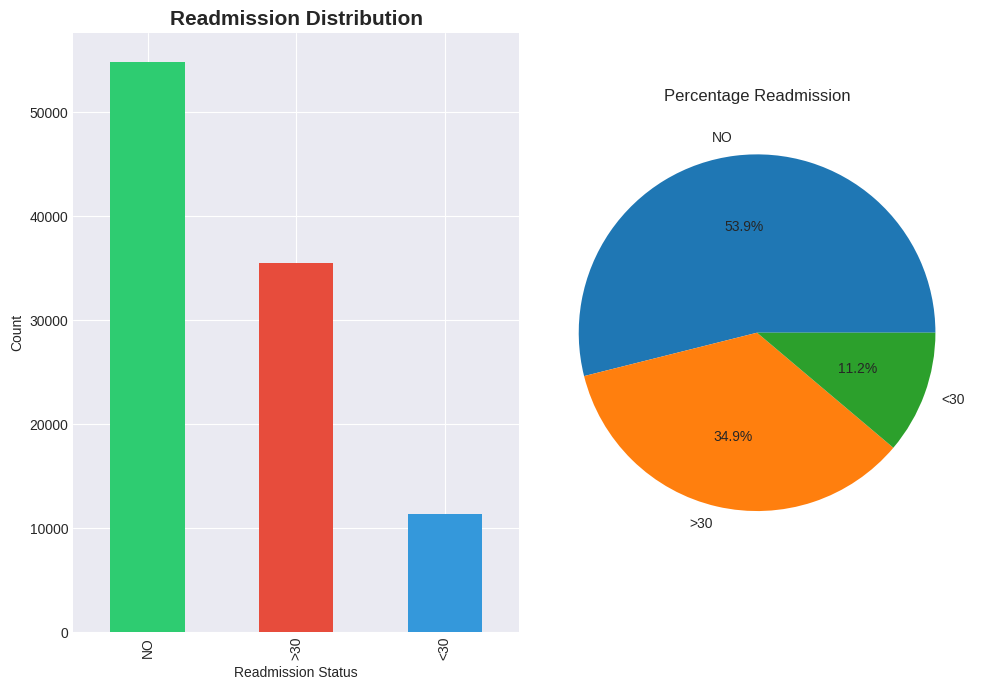

In [13]:
# Target Value Distribution
print("our problem statement is to find the diabetic people who are readmitted ")
print("so our target column is readmitted")

if 'readmitted' in df_raw.columns:
   people_readmitted = df_raw['readmitted'].value_counts() #hr category mn kitna count hai btata hai ye .value_counts

print(f"The number of People Readmitted are :{people_readmitted}")
percentage_readmission = people_readmitted / len(df_raw) *100
print(f"The percentage of People Readmitted are :\n{percentage_readmission}")



# Visulaisation OF TARGET Distribution
plt.figure(figsize = (10,7))
plt.subplot(1,2,1)
people_readmitted.plot(kind='bar' ,color=['#2ecc71', '#e74c3c', '#3498db'])


plt.title("Readmission Distribution", fontsize = 15, fontweight = 'bold')
plt.xlabel("Readmission Status")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.pie(people_readmitted.values,labels=people_readmitted.index, autopct="%1.1f%%")
plt.title("Percentage Readmission")
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: '01_target_distribution.png'")
plt.show()

# Data Cleaning and Preprocessing

In [14]:
# 1) handle missing/placeholder values
# 2) remove unncessary columns
# 3) convert data types
# 4) create binary target variable (for modling simplification)

#4.1 replacing place holders with nan{its not a string but np.nan which says that its missing}
print("Replacing the place holder Values. '?'  with 'NaN'")
print("-"*80)
df = df.replace('?', np.nan)


Replacing the place holder Values. '?'  with 'NaN'
--------------------------------------------------------------------------------


In [15]:
#4.2 dropping column with high missing value rate
print("Removing all problematic columns")
print("-"* 80)
column_to_drop = [

    'weight', # have place holders values upto 90
    'medical_specialty', # 49% of data has place holder values
    'payer_code', # 39% of data is missing
    'encounter_id', #identifier wont help in prediction
    'patient_nbr' #identifier wont help in prediction

]
print(f"Dropping {len(column_to_drop)} columns")
for col in column_to_drop:
  if col in df.columns:
    missing_pct = df[col].isnull().sum() / len( df)*100
    print(f"{col}: {round(missing_pct,2)} % missing")
    df = df.drop(columns = [col])

print(f"New Data Set Shape : {df.shape[0]} rows : {df.shape[1]} columns")

Removing all problematic columns
--------------------------------------------------------------------------------
Dropping 5 columns
weight: 96.86 % missing
medical_specialty: 49.08 % missing
payer_code: 39.56 % missing
encounter_id: 0.0 % missing
patient_nbr: 0.0 % missing
New Data Set Shape : 101766 rows : 45 columns


In [19]:
#4.3 Hnadling Remaining Missing Values
print("Handling Remaining Missing Values")
print("-"*80)
#so we got 7 column that had place holder values
#we droped 3 of them which were weight, medical speciality and payer
# next we are handling the remaing columns that had unknown values
# so the numerical data we filled it with nan
# for the text data we are filling it with the unknown text

catagorical_fill_column = ['race', 'gender', 'diag_1', 'diag_2', 'diag_3']
for col in catagorical_fill_column:
  count_of_missing_vals = df[col].isnull().sum()
  print(f"{col}: {count_of_missing_vals} missing values")
  df[col] = df[col].fillna('unknown')
  print(f"{col} : Filled  { count_of_missing_vals} missing values with 'unknown' ")


  print ("Categorical Values Handled")



#4.4 Creating Binary Target Variable
#what is our target variable -> readmitted right -> it has answers like 0,<30, >39
#we cannot predict using that kind of data
#Because machine learning models work with numbers, not text. You cannot feed <30 or NO into a model directly.
#what we are doin is we are converting them in 0 , 1 for --> { >30,0 == 0 ,  <30 ==1 }
print("Creating Binary Target Variable")
print("3 class target to binary")
if 'readmitted' in df.columns:
  df['binary_readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
binary_readmitted_count = df['binary_readmitted'].value_counts()
percentage_binary_readmission = binary_readmitted_count/ len(df) *100
print(f"The number of People Readmitted are :{binary_readmitted_count}")
print(f"The percentage of People Readmitted are :\n{percentage_binary_readmission}")


# okay so 88% of patients didnt readmitted
# if we put this data into a model it will fail
# so which and what kind of model to use we need to find what is the imbalace ratio
# Accuracy lies when classes are imbalanced. The ratio tells you how badly your model could be fooled and forces you to choose the right tools before wasting time training a broken model.

imbalance_ratio = binary_readmitted_count[0]/binary_readmitted_count[1]
print (f"the class imbalace ration is {round(imbalance_ratio,2)}")
print("(This is important for model selection and evaluation)")

#4.5
#Columns that are object (string) but should be numeric → need engineering
#Columns that are numeric but actually represent categories → need engineering
def categorizing_diag(diag_code):
  if diag_code =='unknown' or pd.isna(diag_code):
    return diag_code
  diag_str =str(diag_code)
  if diag_str.startswith('E') or diag_str.startswith('V'):
    return 'other'

  # ICD-9 code ranges (simplified)
  try:
      code = float(diag_str)
      if 390 <= code <= 459 or code == 785:
                return 'Circulatory'
      elif 460 <= code <= 519 or code == 786:
                return 'Respiratory'
      elif 520 <= code <= 579 or code == 787:
                return 'Digestive'
      elif 250 <= code < 251:
                return 'Diabetes'
      elif 800 <= code <= 999:
                return 'Injury'
      elif 710 <= code <= 739:
                return 'Musculoskeletal'
      elif 580 <= code <= 629 or code == 788:
                return 'Genitourinary'
      elif 140 <= code <= 239:
                return 'Neoplasms'
      else:
                return 'Other'
  except:

        return 'Other'



#now calling this function for the diag columns
for diag_col in ['diag_1','diag_2','diag_3']:
  if diag_col in df.columns:
    new_diag_col_name = f'{diag_col}_category'
    df[new_diag_col_name] = df[diag_col].apply(categorizing_diag)
    print("-"*80)
  print(f"New column created: {new_diag_col_name }")
  print(f"{df[new_diag_col_name].value_counts().to_dict()}")


Handling Remaining Missing Values
--------------------------------------------------------------------------------
race: 2273 missing values
race : Filled  2273 missing values with 'unknown' 
Categorical Values Handled
gender: 0 missing values
gender : Filled  0 missing values with 'unknown' 
Categorical Values Handled
diag_1: 21 missing values
diag_1 : Filled  21 missing values with 'unknown' 
Categorical Values Handled
diag_2: 358 missing values
diag_2 : Filled  358 missing values with 'unknown' 
Categorical Values Handled
diag_3: 1423 missing values
diag_3 : Filled  1423 missing values with 'unknown' 
Categorical Values Handled
Creating Binary Target Variable
3 class target to binary
The number of People Readmitted are :binary_readmitted
0    90409
1    11357
Name: count, dtype: int64
The percentage of People Readmitted are :
binary_readmitted
0    88.840084
1    11.159916
Name: count, dtype: float64
the class imbalace ration is 7.96
(This is important for model selection and evalua

In [20]:
#4.6 Converting age into numeric data
print("Converting age into numeric data")
print("-"*80)
if 'age' in df.columns:
     age_mapping = {
         '[0-10)' : 5,
         '[10-20)' : 15,
         '[20-30)':  25,
         '[30-40)' : 35,
         '[40-50)' : 45,
         '[50-60)' : 54,
         '[60-70)' : 64,
         '[70-80)' : 74,
         '[80-90)' : 84,
         '[90-100)': 94
     }

     df['age_numeric'] = df['age'].map(age_mapping)
     print("Age column converted to numeric")
     print(f"  Range: {df['age_numeric'].min()} - {df['age_numeric'].max()} years")
print("="*80)

print("Data Cleaning Completed")

print("Saving the cleaned data")

print(f"Cleaned data shape :  {df.shape[0]} rows x {df.shape[1]} columns")
output_file = 'cleaned_diabetic_data.csv'
df.to_csv(output_file, index=False)
print(f"Cleaned data saved to: {output_file}")

#


Converting age into numeric data
--------------------------------------------------------------------------------
Age column converted to numeric
  Range: 5 - 94 years
Data Cleaning Completed
Saving the cleaned data
Cleaned data shape :  101766 rows x 50 columns
Cleaned data saved to: cleaned_diabetic_data.csv


# Cleaned Data Summary

In [21]:
# ============================================================================
# SECTION 5: CLEANED DATA SUMMARY
# ============================================================================

print("\n\n" + "=" * 80)
print("CLEANED DATASET SUMMARY")
print("=" * 80)



CLEANED DATASET SUMMARY


In [22]:
# 5.1 Numeric features summary
print("\n1. NUMERIC FEATURES SUMMARY")
print("-" * 80)

#the line below will find all the columns with numeric data
numeric_features = df.select_dtypes(include = [np.number]).columns.to_list()
print (f"Number of numeric features : {len(numeric_features)}")


key_numeric_features = ['age_numeric','time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

print ("\n Key Numeric Features")

for num_col in key_numeric_features:
  if num_col in df.columns:
    print("="*80)
    print(f"{num_col}")
    print("="*80)
    print(f"Mean : {df[num_col].mean():.2f}")
    print(f"Median : {df[num_col].median():.2f}")
    print(f"Standard Deviation : {df[num_col].std():.2f}")
    print(f"Minimum : {df[num_col].min():.2f} - Maximum : {df[num_col].max():.2f}")
    print(f"Range : {df[num_col].max() - df[num_col].min():.2f}")

 # 5.2 Categorical features summary
print("\n1. Categorical FEATURES SUMMARY")
print("-" * 80)

categorical_features = df.select_dtypes(include = ['object']).columns.tolist()
print (f"Number of categorical features : {len(categorical_features)}")

print("Key Categorical Features\n\n")
key_categorical_features = ['race','gender','admission_type_id', 'discharge_disposition_id',
                   'admission_source_id', 'diag_1_category', 'diabetesMed', 'change']
for cat_col in key_categorical_features:
  if cat_col in df.columns:
    unique_count = df[cat_col].nunique()
    print("="*80)
    print(f"{cat_col} : {unique_count} categories")
    print("="*80)

    if unique_count <= 10:
      print("\n=\n")
      print(f"{df[cat_col].value_counts().head()}")


1. NUMERIC FEATURES SUMMARY
--------------------------------------------------------------------------------
Number of numeric features : 13

 Key Numeric Features
age_numeric
Mean : 65.12
Median : 64.00
Standard Deviation : 15.68
Minimum : 5.00 - Maximum : 94.00
Range : 89.00
time_in_hospital
Mean : 4.40
Median : 4.00
Standard Deviation : 2.99
Minimum : 1.00 - Maximum : 14.00
Range : 13.00
num_lab_procedures
Mean : 43.10
Median : 44.00
Standard Deviation : 19.67
Minimum : 1.00 - Maximum : 132.00
Range : 131.00
num_procedures
Mean : 1.34
Median : 1.00
Standard Deviation : 1.71
Minimum : 0.00 - Maximum : 6.00
Range : 6.00
num_medications
Mean : 16.02
Median : 15.00
Standard Deviation : 8.13
Minimum : 1.00 - Maximum : 81.00
Range : 80.00
number_outpatient
Mean : 0.37
Median : 0.00
Standard Deviation : 1.27
Minimum : 0.00 - Maximum : 42.00
Range : 42.00
number_emergency
Mean : 0.20
Median : 0.00
Standard Deviation : 0.93
Minimum : 0.00 - Maximum : 76.00
Range : 76.00
number_inpatient
Mea

In [23]:
# 5.3 Final Data Quality Check

print(f"\nNumber of records:{ len(df)}")
print(f"\nNumber of Fetures: {df.shape[1]}")

missing_values = df.isnull().sum().sum()
print(f"\nMissing Values: {missing_values}")
if missing_values > 0:
  print(f"\n Missing Values Percentage : {missing_values / (df.shape[0]* df.shape[1]) * 100.:4f}%")
else:
  print("\nNo Missing Values")
print("\n✓ Dataset is clean and ready for analysis!")


Number of records:101766

Number of Fetures: 50

Missing Values: 181168

 Missing Values Percentage : 3.560482%

✓ Dataset is clean and ready for analysis!


# EXPLORATORY DATA ANALYSIS (EDA)



Created Visualizations Directory

1. UNIVARIATE ANALYSIS - NUMERIC FEATURES
--------------------------------------------------------------------------------

✓ Visualization saved: 'visualizations/01_univariate_numeric.png'


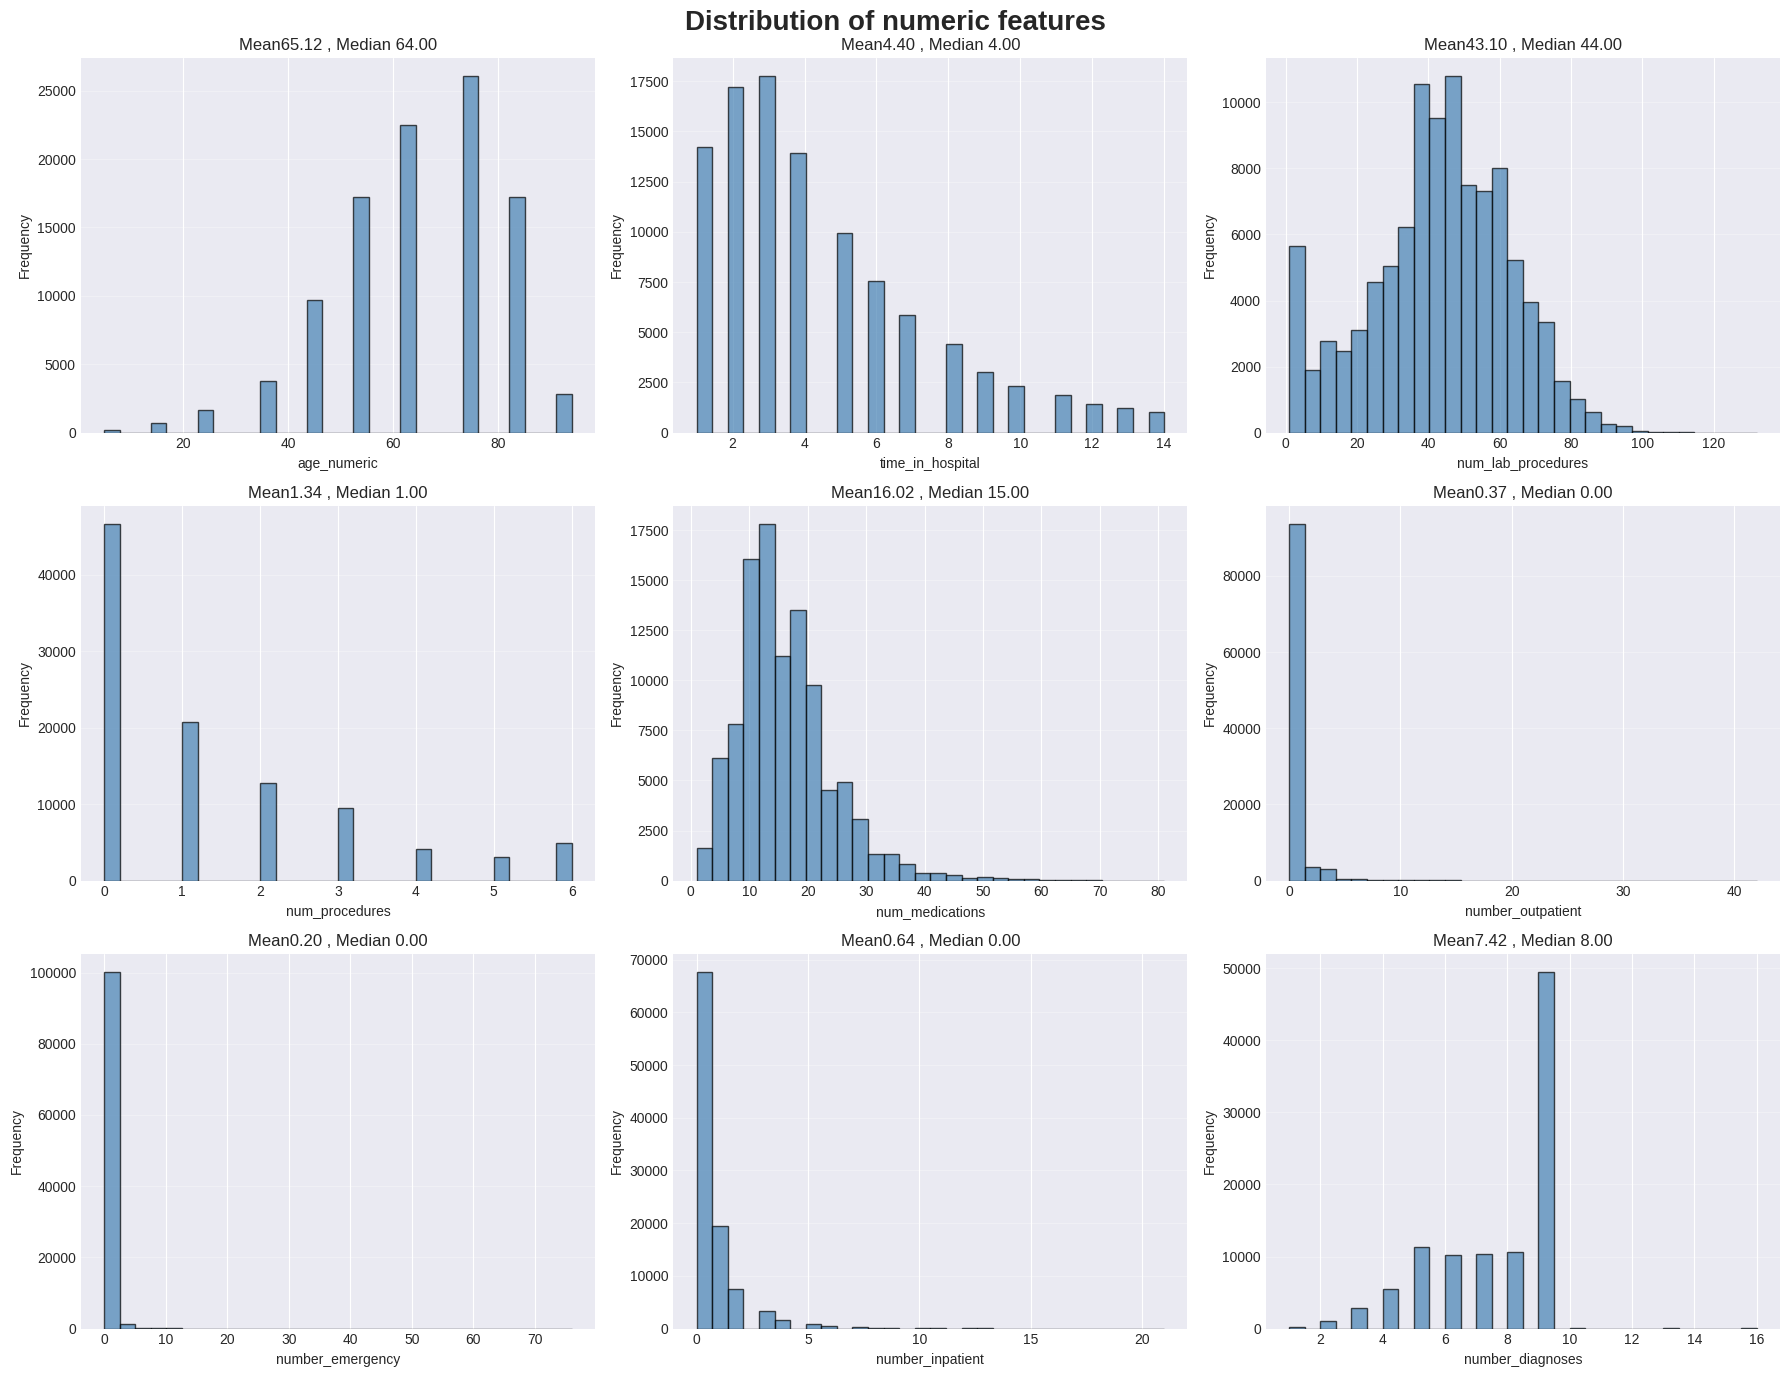

--------------------------------------------------------------------------------
Statistiacal Summary of the numeric features
--------------------------------------------------------------------------------
       age_numeric  time_in_hospital  num_lab_procedures  num_procedures  \
count    101766.00         101766.00           101766.00       101766.00   
mean         65.12              4.40               43.10            1.34   
std          15.68              2.99               19.67            1.71   
min           5.00              1.00                1.00            0.00   
25%          54.00              2.00               31.00            0.00   
50%          64.00              4.00               44.00            1.00   
75%          74.00              6.00               57.00            2.00   
max          94.00             14.00              132.00            6.00   

       num_medications  number_outpatient  number_emergency  number_inpatient  \
count        101766.00     

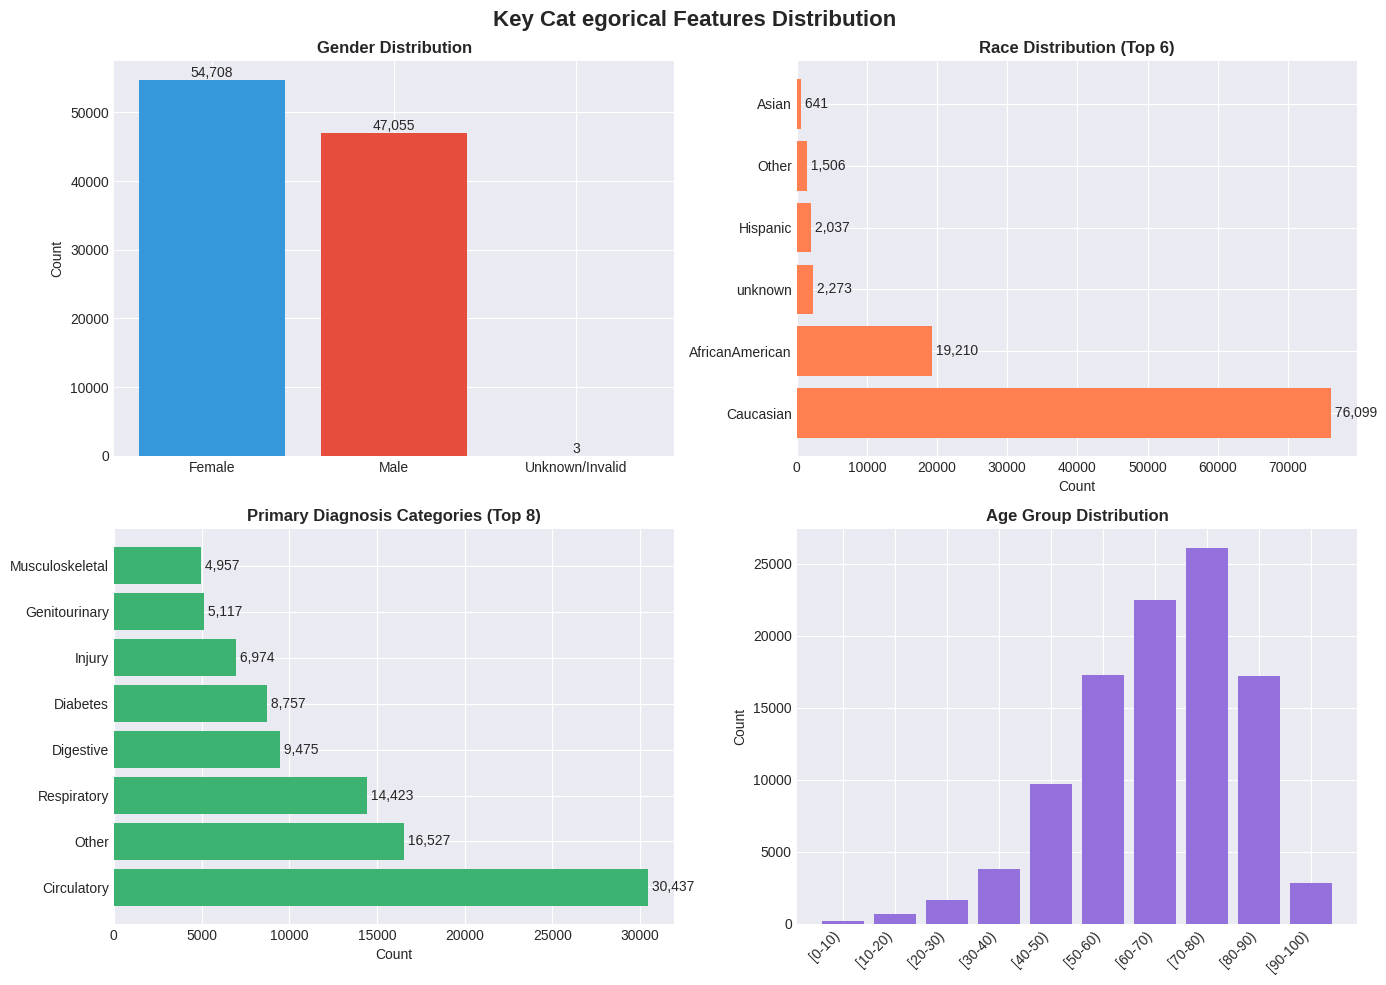

In [24]:

"""
EDA helps us understand:
1. Individual feature distributions
2. Relationships between features
3. Patterns related to readmission
4. Data-driven insights for healthcare stakeholders

We'll create comprehensive visualizations that tell a story.
"""
# EDA = Looking at your data from every angle to:

# Understand what you have
# Find patterns and relationships
# Spot problems (outliers, errors, weird distributions)
# Generate insights and hypotheses
# Decide what to do next (which models to use, what features matter)


#creating a directory for visualizations
import os
if not os.path.exists('visualizations'):
  os.mkdir('visualizations')
  print("Created Visualizations Directory")

# 6.1 UNIVARIATE ANALYSIS - NUMERIC FEATURES
print("\n1. UNIVARIATE ANALYSIS - NUMERIC FEATURES")
print("-" * 80)

# we in the previous section found out our key numerc features


#create distribution plots for each key numerical feature

# plt.subplot(3, 3, 1) = Singular, old way, activates one subplot at a time
# plt.subplots(3, 3) = Plural, modern way, creates all subplots at once ✅
figure,axes = plt.subplots(3,3,figsize = (18,14))
figure.suptitle("Distribution of numeric features", fontsize = 20, fontweight = 'bold')

# Normal for loop gives you just the value. enumerate gives you both the index and the value:
for idx,col in enumerate(key_numeric_features):
  if col in df.columns:
    row = idx//3
    column = idx%3
    ax = axes[row,column]
    df[col].hist(ax = ax, bins = 30, alpha = 0.7 , color = 'steelblue' ,edgecolor = 'black')

    ax.set_title(f"Mean{df[col].mean():.2f} , Median {df[col].median():.2f}")
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.savefig('visualizations/01_univariate_numeric.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: 'visualizations/01_univariate_numeric.png'")
plt.show()


print("-" * 80)
print("Statistiacal Summary of the numeric features")
print("-" * 80)
print(df[key_numeric_features].describe().round(2))

# 6.1 UNIVARIATE ANALYSIS - Categorical FEATURES
print("\n1. UNIVARIATE ANALYSIS - Categorical FEATURES")
print("-" * 80)


# Gender distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Cat egorical Features Distribution', fontsize=16, fontweight='bold')

# Gender
if 'gender' in df.columns:
    gender_counts = df['gender'].value_counts()
    axes[0, 0].bar(gender_counts.index, gender_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'])
    axes[0, 0].set_title('Gender Distribution', fontweight='bold')
    axes[0, 0].set_ylabel('Count')
    for i, v in enumerate(gender_counts.values):
        axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Race
if 'race' in df.columns:
    race_counts = df['race'].value_counts().head(6)
    axes[0, 1].barh(race_counts.index, race_counts.values, color='coral')
    axes[0, 1].set_title('Race Distribution (Top 6)', fontweight='bold')
    axes[0, 1].set_xlabel('Count')
    for i, v in enumerate(race_counts.values):
        axes[0, 1].text(v, i, f' {v:,}', va='center')

# Primary Diagnosis Category
if 'diag_1_category' in df.columns:
    diag_counts = df['diag_1_category'].value_counts().head(8)
    axes[1, 0].barh(diag_counts.index, diag_counts.values, color='mediumseagreen')
    axes[1, 0].set_title('Primary Diagnosis Categories (Top 8)', fontweight='bold')
    axes[1, 0].set_xlabel('Count')
    for i, v in enumerate(diag_counts.values):
        axes[1, 0].text(v, i, f' {v:,}', va='center')

# Age Distribution
if 'age' in df.columns:
    age_counts = df['age'].value_counts().sort_index()
    axes[1, 1].bar(range(len(age_counts)), age_counts.values, color='mediumpurple')
    axes[1, 1].set_title('Age Group Distribution', fontweight='bold')
    axes[1, 1].set_xticks(range(len(age_counts)))
    axes[1, 1].set_xticklabels(age_counts.index, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Count')


plt.tight_layout()
plt.savefig('visualizations/02_univarite_categorical.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: 'visualizations/02_univarite_categorical.png'")
plt.show()





3. BIVARIATE ANALYSIS - RELATIONSHIP WITH READMISSION
--------------------------------------------------------------------------------

✓ Visualization saved: 'visualizations/03_bivariate_numeric.png'


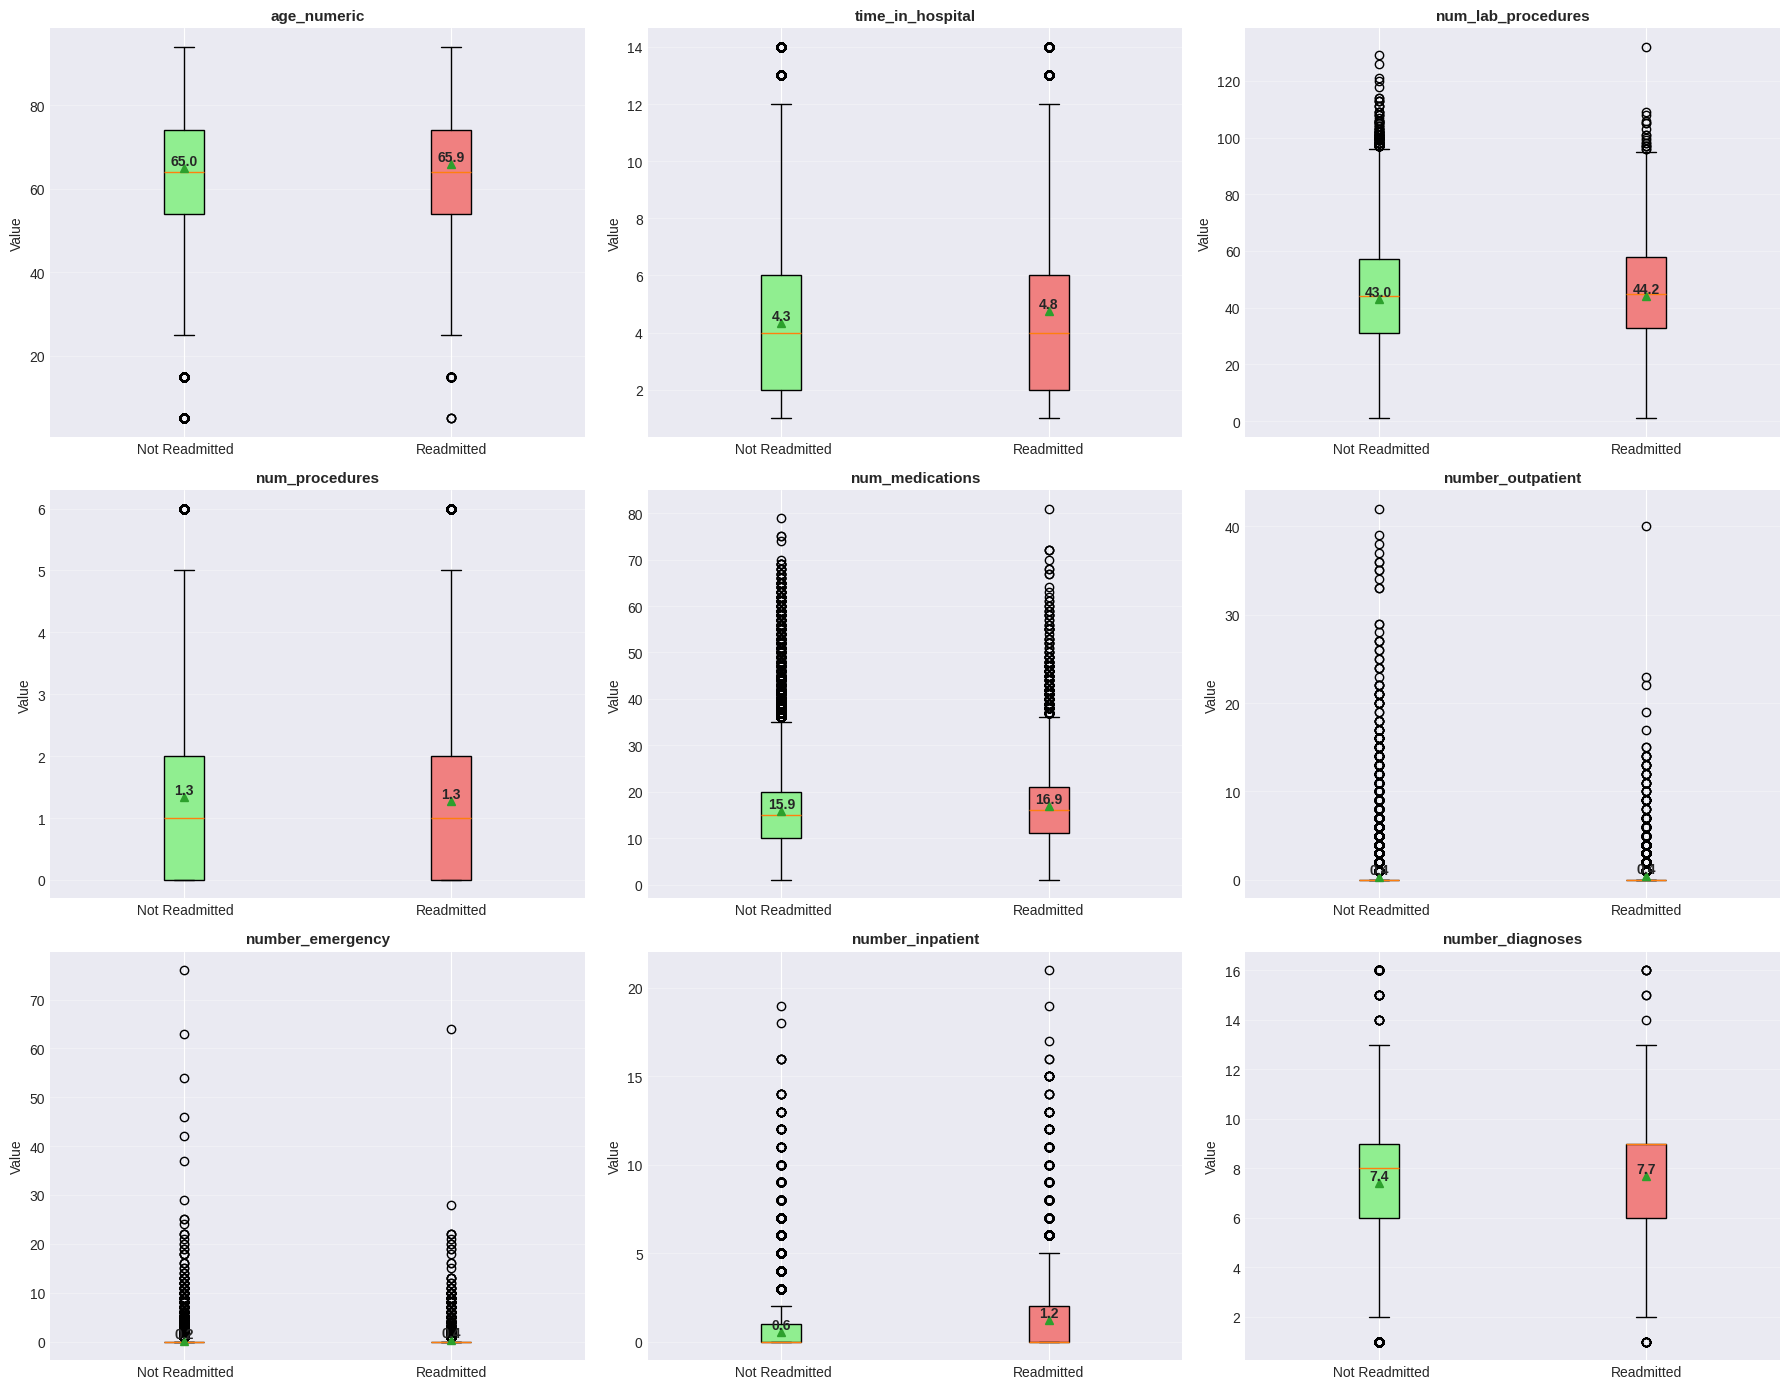

age_numeric:
  Not Readmitted: 65.02
  Readmitted: 65.91
  Difference: -0.89 (-1.4%)

time_in_hospital:
  Not Readmitted: 4.35
  Readmitted: 4.77
  Difference: -0.42 (-9.6%)

num_lab_procedures:
  Not Readmitted: 42.95
  Readmitted: 44.23
  Difference: -1.27 (-3.0%)

num_procedures:
  Not Readmitted: 1.35
  Readmitted: 1.28
  Difference: +0.07 (+4.9%)

num_medications:
  Not Readmitted: 15.91
  Readmitted: 16.90
  Difference: -0.99 (-6.2%)

number_outpatient:
  Not Readmitted: 0.36
  Readmitted: 0.44
  Difference: -0.08 (-21.1%)

number_emergency:
  Not Readmitted: 0.18
  Readmitted: 0.36
  Difference: -0.18 (-101.0%)

number_inpatient:
  Not Readmitted: 0.56
  Readmitted: 1.22
  Difference: -0.66 (-117.9%)

number_diagnoses:
  Not Readmitted: 7.39
  Readmitted: 7.69
  Difference: -0.30 (-4.1%)



3.2 CATEGORICAL FEATURES VS READMISSION
--------------------------------------------------------------------------------
✓ Saved: visualizations/05_categorical_vs_readmission.png


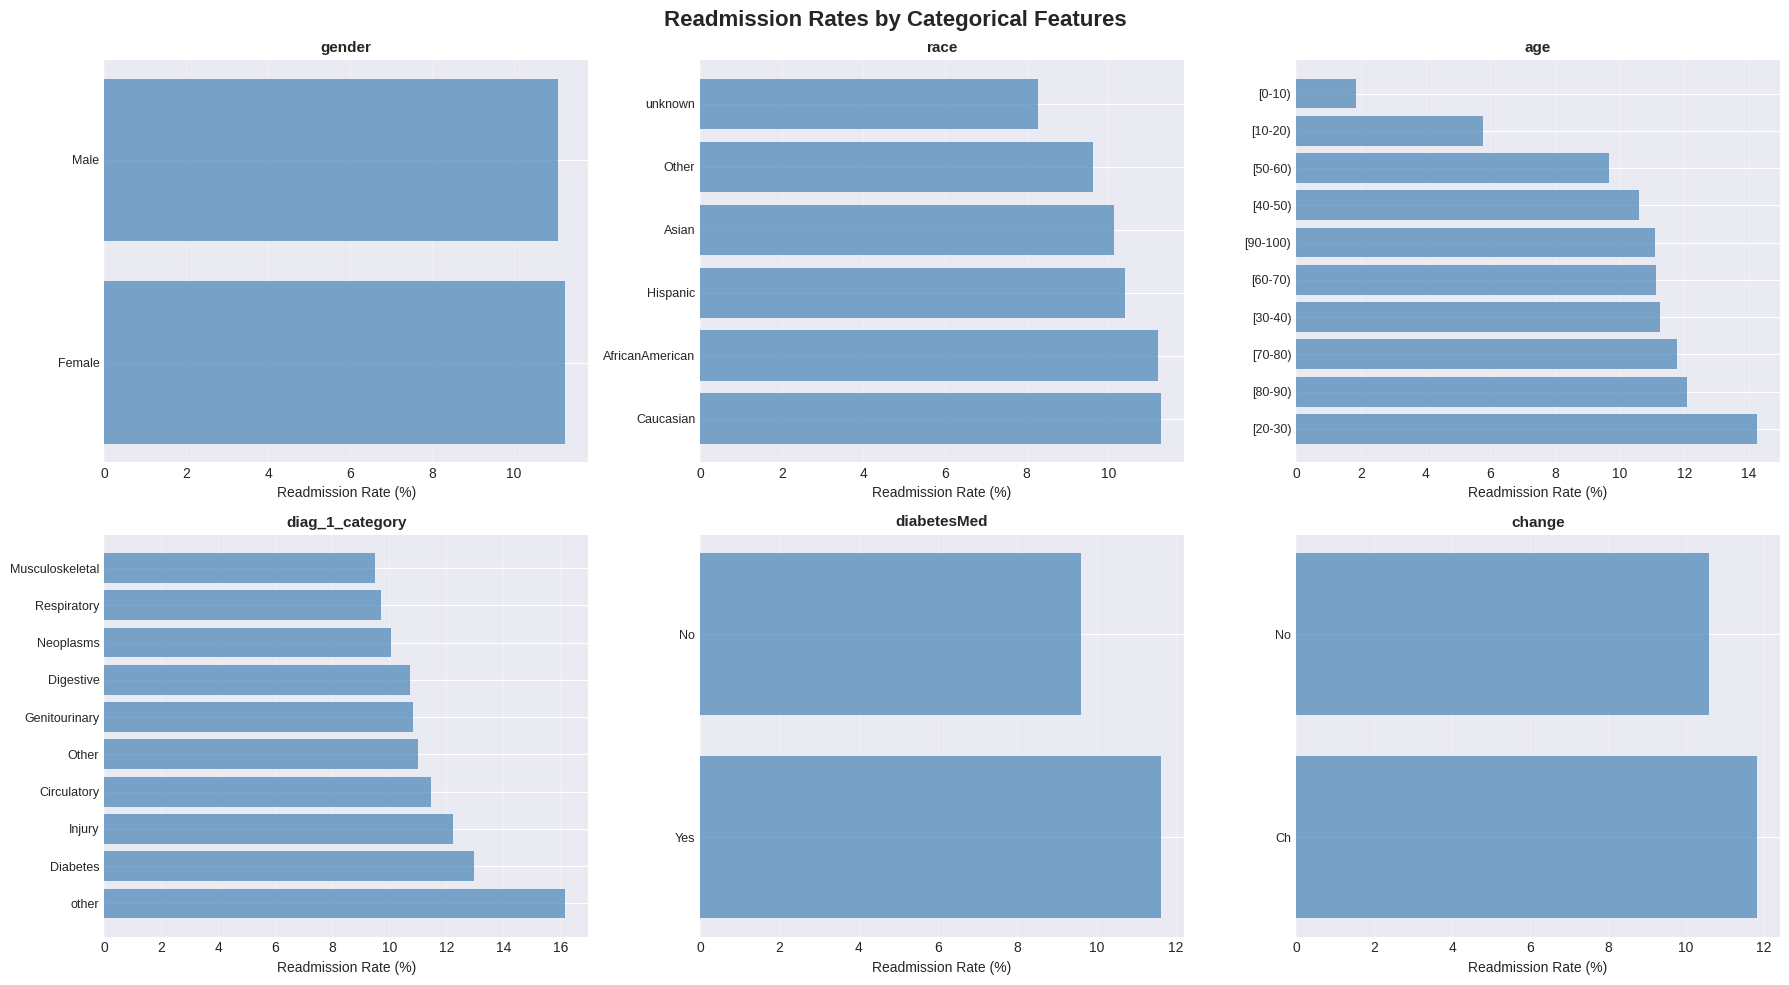



3.3 CORRELATION ANALYSIS
--------------------------------------------------------------------------------
✓ Saved: visualizations/06_correlation_matrix.png


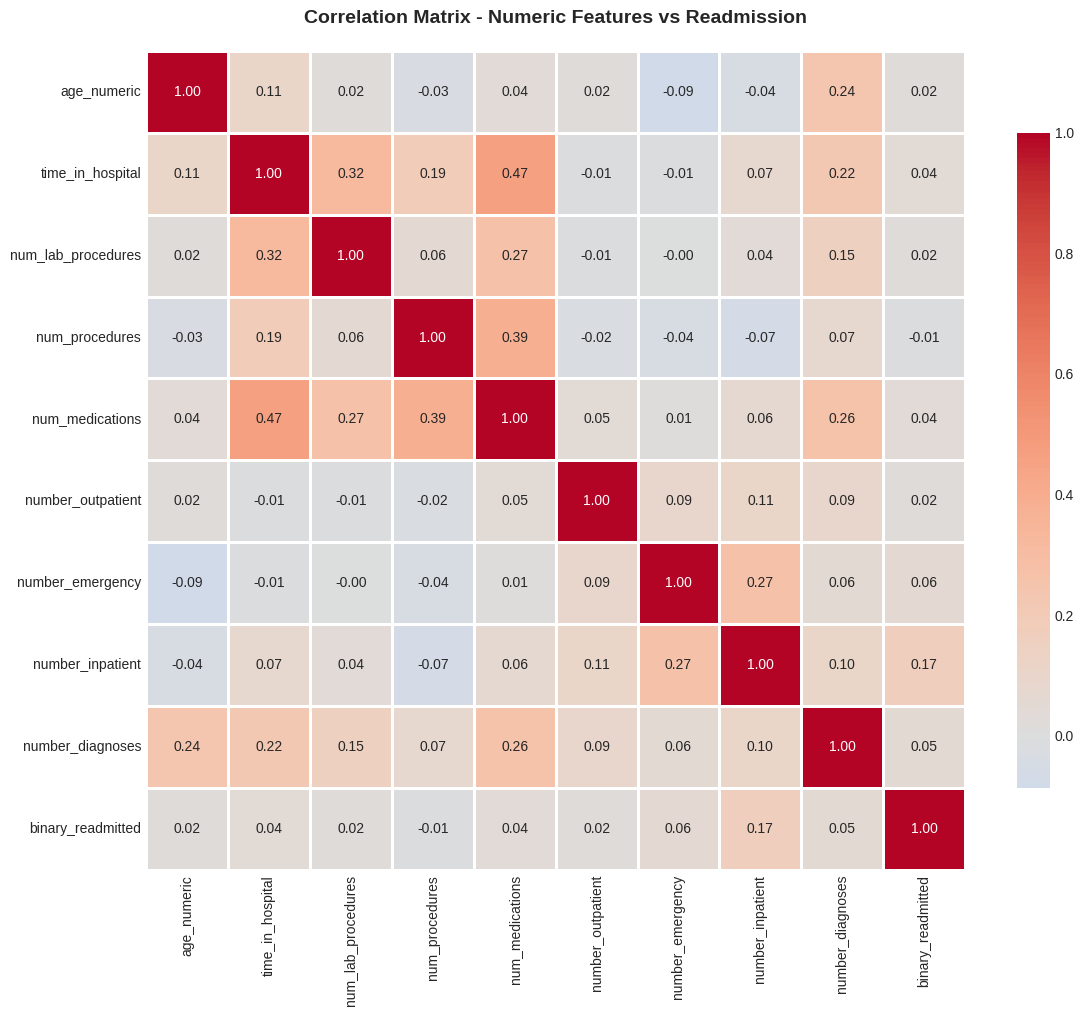


Top Correlations with Readmission:
--------------------------------------------------------------------------------
number_inpatient      0.165147
number_emergency      0.060747
number_diagnoses      0.049524
time_in_hospital      0.044199
num_medications       0.038432
num_lab_procedures    0.020364
number_outpatient     0.018893
age_numeric           0.017829
num_procedures       -0.012227

1. PATIENT DEMOGRAPHICS
--------------------------------------------------------------------------------
Gender Distribution:

  Female: 53.8%
  Male: 46.2%
  Unknown/Invalid: 0.0%

Age Statistics:
  - Mean Age: 65.1 years
  - Median Age: 64.0 years
  - Patients over 60: 67.4%

2. READMISSION STATISTICS
--------------------------------------------------------------------------------
Overall 30-Day Readmission Rate: 11.16%
Total Readmitted (< 30 days): 11,357 out of 101,766


In [25]:
# 6.3 BIVARIATE ANALYSIS - FEATURES VS TARGET
print("\n\n3. BIVARIATE ANALYSIS - RELATIONSHIP WITH READMISSION")
print("-" * 80)
figs, axes = plt.subplots(3,3, figsize=(18,14))
fig.suptitle('Bivariate Analysis of Features vs Target', fontsize=16, fontweight='bold',y=1.00)
for idx,col in enumerate(key_numeric_features):
  if col in df.columns:
    row = idx // 3
    column = idx % 3
    ax = axes[row,column]
    data_to_plot = [

        df[df['binary_readmitted'] == 0][col].dropna(),
        df[df['binary_readmitted'] == 1][col].dropna()
    ]
    bp = ax.boxplot(data_to_plot, labels = [' Not Readmitted','Readmitted'], patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')

    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)
#adding mean values as text
    mean_0 = df[df['binary_readmitted'] == 0 ][col].mean()
    mean_1 = df[df['binary_readmitted'] == 1][col].mean()

    ax.text(1, mean_0, f'{mean_0:.1f}', ha='center', va='bottom', fontweight='bold')
    ax.text(2, mean_1, f'{mean_1:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/03_bivariate_numeric.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: 'visualizations/03_bivariate_numeric.png'")
plt.show()


# Calculate and display statistical differences

for col in key_numeric_features:
  if col in df.columns:
    mean_not_readmitted = df[df['binary_readmitted']== 0 ][col].mean()
    mean_readmitted = df[df['binary_readmitted']== 1 ][col].mean()
    diff_mean = mean_not_readmitted - mean_readmitted
    pct_diff = (diff_mean/ mean_not_readmitted * 100) if mean_not_readmitted != 0 else 0

    print(f"{col}:")
    print(f"  Not Readmitted: {mean_not_readmitted:.2f}")
    print(f"  Readmitted: {mean_readmitted:.2f}")
    print(f"  Difference: {diff_mean:+.2f} ({pct_diff:+.1f}%)")
    print()



# 6.3.2 Categorical features vs Readmission
print("\n\n3.2 CATEGORICAL FEATURES VS READMISSION")
print("-" * 80)

# Readmission rate by key categorical features
categorical_features = ['gender', 'race', 'age', 'diag_1_category', 'diabetesMed', 'change']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Readmission Rates by Categorical Features', fontsize=16, fontweight='bold')

for index,col in enumerate(categorical_features):
  rows = index//3
  columns = index%3
  ax =  axes[rows,columns]
  readmit_rate = df.groupby(col)['binary_readmitted'].agg(['mean', 'count'])
  readmit_rate = readmit_rate[readmit_rate['count'] >= 100]
  readmit_rate = readmit_rate.sort_values(by = 'mean', ascending = False)


  bars = ax.barh(range(len(readmit_rate)), readmit_rate['mean'] * 100,
                       color='steelblue', alpha=0.7)
  ax.set_yticks(range(len(readmit_rate)))
  ax.set_yticklabels(readmit_rate.index, fontsize=9)
  ax.set_xlabel('Readmission Rate (%)', fontsize=10)
  ax.set_title(f'{col}', fontsize=11, fontweight='bold')
  ax.grid(axis='x', alpha=0.3)


plt.tight_layout()
plt.savefig('visualizations/05_categorical_vs_readmission.png', dpi=300, bbox_inches='tight')
print("✓ Saved: visualizations/05_categorical_vs_readmission.png")
plt.show()


# 6.3.3 Correlation Analysis
print("\n\n3.3 CORRELATION ANALYSIS")
print("-" * 80)

corr_columns = [col for col in key_numeric_features if col in df.columns ]
corr_columns.append('binary_readmitted')
correlation_matrix = df[corr_columns].corr()

#plotting the heat map

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numeric Features vs Readmission',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualizations/06_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: visualizations/06_correlation_matrix.png")
plt.show()


# Print top correlations with target
print("\nTop Correlations with Readmission:")
print("-" * 80)
target_corr = correlation_matrix['binary_readmitted'].drop('binary_readmitted').sort_values(
    key=abs, ascending=False
)
print(target_corr.to_string())



# 7.1 Calculate key statistics for insights
print("\n1. PATIENT DEMOGRAPHICS")
print("-" * 80)
if 'gender' in df.columns:
   gender_dist = df['gender'].value_counts(normalize=True)*100
   print(f"Gender Distribution:\n")
   for gender,pct in gender_dist.items():
     print(f"  {gender}: {pct:.1f}%")
if 'age_numeric' in df.columns:
   print(f"\nAge Statistics:")
   print(f"  - Mean Age: {df['age_numeric'].mean():.1f} years")
   print(f"  - Median Age: {df['age_numeric'].median():.1f} years")
   print(f"  - Patients over 60: {(df['age_numeric'] >= 60).sum() / len(df) * 100:.1f}%")

print("\n2. READMISSION STATISTICS")
print("-" * 80)

total_patients = len(df)
readmitted_30 = (df['binary_readmitted'] == 1).sum()
readmission_rate = readmitted_30 / total_patients * 100

print(f"Overall 30-Day Readmission Rate: {readmission_rate:.2f}%")
print(f"Total Readmitted (< 30 days): {readmitted_30:,} out of {total_patients:,}")


# KEY INSIGHTS FROM EDA



In [26]:
print("\n\n" + "=" * 80)
print("KEY INSIGHTS FROM EXPLORATORY ANALYSIS")
print("=" * 80)

"""
Summarize the most important findings that will guide our modeling
and provide actionable insights for healthcare stakeholders.
"""

print("\n1. PATIENT DEMOGRAPHICS")
print("-" * 80)

if 'gender' in df.columns:
    gender_dist = df['gender'].value_counts(normalize=True) * 100
    print(f"Gender Distribution:")
    for gender, pct in gender_dist.items():
        print(f"  - {gender}: {pct:.1f}%")

if 'age_numeric' in df.columns:
    print(f"\nAge Statistics:")
    print(f"  - Mean Age: {df['age_numeric'].mean():.1f} years")
    print(f"  - Median Age: {df['age_numeric'].median():.1f} years")
    print(f"  - Patients over 60: {(df['age_numeric'] >= 60).sum() / len(df) * 100:.1f}%")


#Readmission statistics
total_patients = len(df)
readmitted_30 = (df['binary_readmitted']== 1).sum()
readmission_rate = readmitted_30/total_patients *100

print(f"Overall 30-Day Readmission Rate: {readmission_rate:.2f}%")
print(f"Total Readmitted (< 30 days): {readmitted_30:,} out of {total_patients:,}")




KEY INSIGHTS FROM EXPLORATORY ANALYSIS

1. PATIENT DEMOGRAPHICS
--------------------------------------------------------------------------------
Gender Distribution:
  - Female: 53.8%
  - Male: 46.2%
  - Unknown/Invalid: 0.0%

Age Statistics:
  - Mean Age: 65.1 years
  - Median Age: 64.0 years
  - Patients over 60: 67.4%
Overall 30-Day Readmission Rate: 11.16%
Total Readmitted (< 30 days): 11,357 out of 101,766


#PREDICTIVE MODELING - DATA PREPARATION

In [27]:
# FEATURE SELECTION / ENCODING( CONVERTING THE CATEGORICAL VARIABLES INTO NUMEBRICAL BCS MODEL CAN ONLY DEAL wth teh numerical data it will throw error if we will use categorical data)
# train/test splitting ->
# scaling -> if we dont do this the model will over fit
# model training


print("\n\n" + "=" * 80)
print("PREDICTIVE MODELING")
print("=" * 80)

print("\n1. FEATURE SELECTION AND ENGINEERING")
print("-" * 80)



# Select features for modeling
# We'll use a mix of demographic, clinical, and administrative features

# Define feature groups

demographical_features = ['race', 'gender', 'age_numeric']
clinical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'diag_1_category',
    'diag_2_category', 'diag_3_category']
utilization_features = ['number_outpatient', 'number_emergency', 'number_inpatient']
medication_features = [ 'diabetesMed', 'change', 'insulin', 'metformin']


#combining all of the features
model_features = demographical_features + clinical_features + utilization_features + medication_features
model_features = [col for col in model_features if col in df.columns ]

print(f"\nFeature categories:")

print (f"number of columns/features  in model_features :  {len(df.columns)}")
print (f"number of DEMOGRAPHICAL_FEATURES {len([f for f in demographical_features if f in model_features])}")
print (f"number of CLINICAL_FEATURES {len([f for f in clinical_features if f in model_features])}")
print (f"number of UTILIZATION_FEATURES {len([f for f in utilization_features if f in model_features])}")
print (f"number of MEDICATION_FEATURES {len([f for f in medication_features if f in model_features])}")


# Create modeling dataset
print("\n2. CREATING MODELING DATASET")
print("-" * 80)


#remove missing rows
df_model = df[model_features + ['binary_readmitted']].copy()
df_model = df_model.dropna(subset = ['binary_readmitted'])


print(f"Initial data set shape : { df.shape} ")
print (f"Data set shape after modeling : { df_model.shape}")
print(f"Rows dropped: {len(df) - len(df_model):,}")


X = df_model[model_features].copy()
Y = df_model['binary_readmitted'].copy()



print(f"\nFeature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {Y.shape}")
print(f"Target distribution: {Y.value_counts().to_dict()}")

#encoding the categorical variables

cat_columns =  X.select_dtypes(include = ['object']).columns.tolist()
print(f"Categorical columns to encode: {len(cat_columns)}")

label_encoders = {}
for col in cat_columns:
  le = LabelEncoder()

#Creates a new LabelEncoder object from sklearn This object will learn the mapping for THIS specific column
#LabelEncoder for 'gender':
#   'Male'    → 1
#   'Female'  → 0
#   'Unknown' → 2
# Why create a new one each time?

# Each column needs its own encoder
# 'Male' in gender ≠ 'Male' in race (different meanings)

  X[col] = le.fit_transform(X[col].astype(str))


#   What it does:

# Converts all values to strings (text)
# Safety measure: ensures everything is text before encoding

# Why needed:
# python# Sometimes you might have mixed types:
# X['gender'] = ['Male', 'Female', np.nan, 'Male']
#                 ↑        ↑         ↑       ↑
#               text     text     float    text

# # .astype(str) makes them all strings:
# X['gender'].astype(str) = ['Male', 'Female', 'nan', 'Male']
#                             ↑        ↑        ↑      ↑
#                           text     text    text   text



# What fit_transform does:
# fit = Learn the unique values
# python# Looks at the data and learns:
# # "gender has 3 unique values: Male, Female, Unknown"
# # "I'll assign: Male=1, Female=0, Unknown=2"
# transform = Apply the encoding
# python# Converts the actual values:
# ['Male', 'Female', 'Male', 'Unknown']
#    ↓       ↓        ↓       ↓
# [  1,      0,       1,       2     ]
# Why combined?

# fit_transform() does both in one step (efficient!)

  label_encoders[col] = le


# What it does:

# Stores the encoder in the dictionary
# Key = column name
# Value = the encoder object

#Thast how it looks
# label_encoders = {
#     'gender': <LabelEncoder for gender>,
#     'race': <LabelEncoder for race>,
#     'age': <LabelEncoder for age>,
#     ...
# }


print(f"  - Encoded {col}: {len(le.classes_)} unique values")

print("\n✓ All categorical variables encoded")

# Check for any remaining missing values


missing_count = X.isnull().sum().sum()


if missing_count > 0:
  print(f"Warning {missing_count} values are missing ..... so filling them with median ")
  X= X.fillna(X.median())
else:
  print("✓ No missing values found")



# 4. TRAIN-TEST SPLIT
print("\n4. TRAIN-TEST SPLIT")
print("-" * 80)

# Split data: 80% training, 20% testing
# Use stratification to maintain class balance


X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2, random_state=42, stratify=Y

)

print(f"Training set size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTraining set class distribution:")
print(Y_train.value_counts())
print(f"  - Class 0 (Not Readmitted): {(Y_train==0).sum()/len(Y_train)*100:.2f}%")
print(f"  - Class 1 (Readmitted): {(Y_train==1).sum()/len(Y_train)*100:.2f}%")

print(f"\nTest set class distribution:")
print(Y_test.value_counts())
print(f"  - Class 0 (Not Readmitted): {(Y_test==0).sum()/len(Y_test)*100:.2f}%")
print(f"  - Class 1 (Readmitted): {(Y_test==1).sum()/len(Y_test)*100:.2f}%")


# 5. FEATURE SCALING
print("\n5. FEATURE SCALING")
print("-" * 80)
print("Scaling features using StandardScaler (mean=0, std=1)")

# Initialize scaler
scaler = StandardScaler()


#What it does:
# Scales your features so each one has mean = 0 and standard deviation = 1.

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #fit_transform(X_test)   ❌  WRONG — leaks test info into your model pipeline



# 1. fit_transform(X_train)

# Learns the mean & std from training data, then scales it
# Only done on X_train to avoid data leakage from test set

# 2. transform(X_test)

# Uses the same mean & std learned from training data to scale the test set
# Does NOT re-learn — this is intentional and correct

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✓ Features scaled successfully")
print(f"\nSample scaled values (first feature):")
print(f"  - Mean: {X_train_scaled.iloc[:, 0].mean():.6f}")
print(f"  - Std Dev: {X_train_scaled.iloc[:, 0].std():.6f}")


## This would print mean of EVERY column — too much output
# print(X_train_scaled.mean())

# This prints just the first column — cleaner for a quick sanity check
# print(X_train_scaled.iloc[:, 0].mean())


print("\n✓ Data preparation complete! Ready for model training.")



PREDICTIVE MODELING

1. FEATURE SELECTION AND ENGINEERING
--------------------------------------------------------------------------------

Feature categories:
number of columns/features  in model_features :  50
number of DEMOGRAPHICAL_FEATURES 3
number of CLINICAL_FEATURES 8
number of UTILIZATION_FEATURES 3
number of MEDICATION_FEATURES 4

2. CREATING MODELING DATASET
--------------------------------------------------------------------------------
Initial data set shape : (101766, 50) 
Data set shape after modeling : (101766, 19)
Rows dropped: 0

Feature matrix (X) shape: (101766, 18)
Target vector (y) shape: (101766,)
Target distribution: {0: 90409, 1: 11357}
Categorical columns to encode: 9
  - Encoded metformin: 4 unique values

✓ All categorical variables encoded
✓ No missing values found

4. TRAIN-TEST SPLIT
--------------------------------------------------------------------------------
Training set size: 81,412 (80.0%)
Testing set size: 20,354 (20.0%)

Training set class dist

#MODEL TRAINING AND EVALUATION





MODEL TRAINING

1. LOGISTIC REGRESSION (Baseline Model)
--------------------------------------------------------------------------------
Training Logistic Regression with class weights...
✓ Model trained successfully

✓ Metrics calculated successfully

Logistic Regression Performance:
  - Training Accuracy: 0.6727
  - Test Accuracy: 0.6699
  - Precision: 0.1707
  - Recall: 0.5077
  - F1 Score: 0.2555
  - ROC AUC: 0.6426


2. RANDOM FOREST CLASSIFIER
--------------------------------------------------------------------------------
Training Random Forest with 100 trees...
✓ Model trained successfully

Random Forest Performance:
  - Training Accuracy: 0.8059
  - Test Accuracy: 0.7552
  - Precision: 0.1939
  - Recall: 0.3782
  - F1 Score: 0.2564
  - ROC AUC: 0.6516


3.Model Comparison
--------------------------------------------------------------------------------

Detailed Matrix Comparison

                     test_accuracy  train_accuracy  Precision  Recall  \
Logistic Regression    

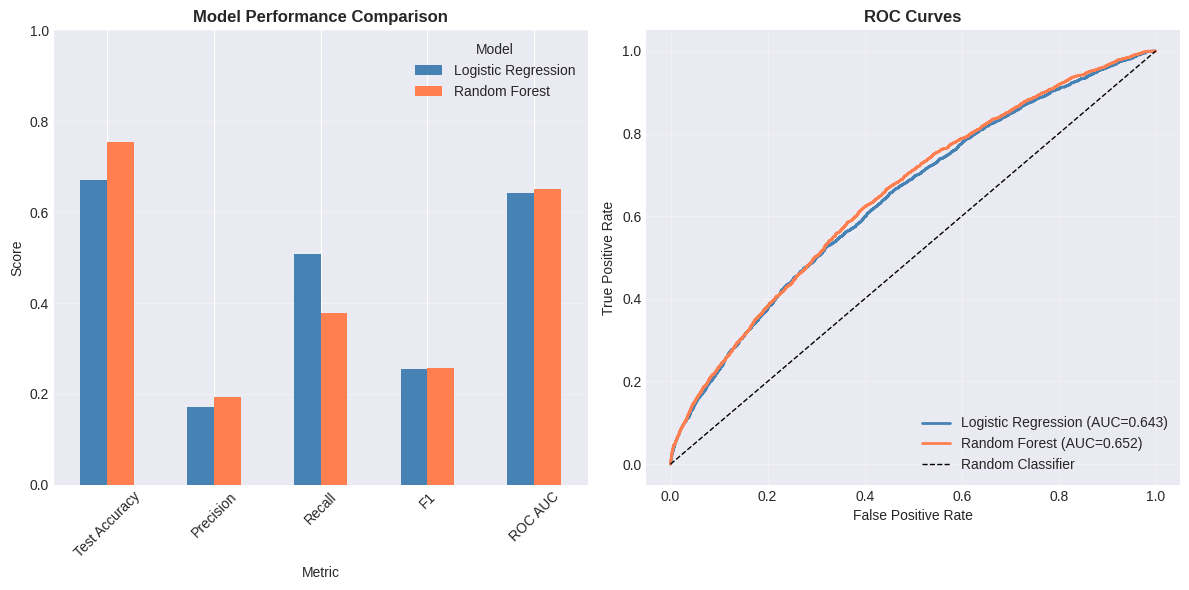

In [28]:

print("\n\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)

"""
We'll train two models:
1. Logistic Regression (baseline, interpretable)
2. Random Forest (more complex, often better performance)

We'll use class weights to handle imbalanced data.
"""
# Dictionary to store models and results
models = {}
results = {}

# 9.1 LOGISTIC REGRESSION
print("\n1. LOGISTIC REGRESSION (Baseline Model)")
print("-" * 80)
print("Training Logistic Regression with class weights...")
lr = LogisticRegression (
    random_state = 42,      #every time you run the model it does thing randomly know as reproductivity
    class_weight = 'balanced',   # Handles class imbalance
    max_iter = 1000,
    solver = 'lbfgs'
)

train_model = lr.fit(X_train_scaled,Y_train)
print("✓ Model trained successfully")

# Make predictions
lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred = lr.predict(X_test_scaled)
lr_pred_proba_test = lr.predict_proba(X_test_scaled)[:,1]
#We pick [:, 1] because:
#We care about "who HAS the disease" — that's the positive class, that's what we're trying to detect.

models['Logistic Regression'] = lr

# Calculate metrics
lr_metrics = {
    'test_accuracy': accuracy_score(Y_test, lr_test_pred),
    'train_accuracy': accuracy_score(Y_train, lr_train_pred),
    'Precision': precision_score(Y_test, lr_test_pred),
    'Recall': recall_score(Y_test, lr_test_pred),
    'F1_Score': f1_score(Y_test, lr_test_pred),
    'auc_roc': roc_auc_score(Y_test, lr_pred_proba_test)
}

results['Logistic Regression'] = lr_metrics

print("\n✓ Metrics calculated successfully")

print("\nLogistic Regression Performance:")
print(f"  - Training Accuracy: {lr_metrics['train_accuracy']:.4f}")
print(f"  - Test Accuracy: {lr_metrics['test_accuracy']:.4f}")
print(f"  - Precision: {lr_metrics['Precision']:.4f}")
print(f"  - Recall: {lr_metrics['Recall']:.4f}")
print(f"  - F1 Score: {lr_metrics['F1_Score']:.4f}")
print(f"  - ROC AUC: {lr_metrics['auc_roc']:.4f}")




# 9.2 RANDOM FOREST
print("\n\n2. RANDOM FOREST CLASSIFIER")
print("-" * 80)

print("Training Random Forest with 100 trees...")

rf_model = RandomForestClassifier(
    max_depth = 15,
    n_estimators = 100,
    random_state = 42,
    class_weight = 'balanced',
    min_samples_leaf=20,
    min_samples_split=50,
    n_jobs= -1
)

# Train model
rf_model.fit(X_train,Y_train)
print("✓ Model trained successfully")

# Make predictions
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
rf_pred_proba_test = rf_model.predict_proba(X_test)[:,1]

models['Random Forest'] = rf_model

#calculate metrics
rf_metrics = {
    'train_accuracy': accuracy_score(Y_train, rf_pred_train),
    'test_accuracy': accuracy_score(Y_test, rf_pred_test),
    'Precision': precision_score(Y_test, rf_pred_test),
    'Recall': recall_score(Y_test, rf_pred_test),
    'F1_Score': f1_score(Y_test, rf_pred_test),
    'auc_roc': roc_auc_score(Y_test, rf_pred_proba_test)
}

results['Random Forest'] = rf_metrics

print("\nRandom Forest Performance:")
print(f"  - Training Accuracy: {rf_metrics['train_accuracy']:.4f}")
print(f"  - Test Accuracy: {rf_metrics['test_accuracy']:.4f}")
print(f"  - Precision: {rf_metrics['Precision']:.4f}")
print(f"  - Recall: {rf_metrics['Recall']:.4f}")
print(f"  - F1 Score: {rf_metrics['F1_Score']:.4f}")
print(f"  - ROC AUC: {rf_metrics['auc_roc']:.4f}")


print("\n\n3.Model Comparison")
print("-" * 80)

comparison_df = pd.DataFrame(results).T  #converting the results dictionary to a data frame


# # Creates this:
#                     Logistic Regression  Random Forest
# test_accuracy                 0.62              0.65
# precision                     0.28              0.32
# recall                        0.45              0.50
# f1                            0.34              0.39
# roc_auc                       0.67              0.72

# Part 3: .T (Transpose)
# Flips rows and columns:
# pythoncomparison_df = pd.DataFrame(results).T

# # Result:
#                       test_accuracy  precision  recall    f1  roc_auc
# Logistic Regression           0.62       0.28    0.45  0.34     0.67
# Random Forest                 0.65       0.32    0.50  0.39     0.72


print("\nDetailed Matrix Comparison\n")
print(comparison_df.round(4))


best_model_name = comparison_df['auc_roc'].idxmax()
#Finds the index (model name) with the maximum value

print(f"\n✓ Best model (by ROC AUC): {best_model_name}")
print(f"  ROC AUC Score: {comparison_df.loc[best_model_name, 'auc_roc']:.4f}")


fig,axes = plt.subplots(1,2,figsize=(12,6))

metrics_to_plot = ['test_accuracy', 'Precision', 'Recall', 'F1_Score', 'auc_roc']
comparison_df[metrics_to_plot].T.plot(kind = 'bar', ax=axes[0],color = ['steelblue' , 'coral'])
axes[0].set_title('Model Performance Comparison', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Metric')
axes[0].set_xticklabels(['Test Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'], rotation=45)
axes[0].legend(title='Model')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])



# ROC = Receiver Operating Characteristic
# Simple definition:
# A graph that shows how good your model is at distinguishing between two classes (readmitted vs not readmitted).




fpr_lr,tpr_lr,_ = roc_curve(Y_test, lr_pred_proba_test)
fpr_rf,tpr_rf,_= roc_curve(Y_test, rf_pred_proba_test)


axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_metrics["auc_roc"]:.3f})',
            linewidth=2, color='steelblue')
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_metrics["auc_roc"]:.3f})',
            linewidth=2, color='coral')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/07_model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: visualizations/07_model_comparison.png")
plt.show()



4. DETAILED MODEL EVALUATION
--------------------------------------------------------------------------------
✓ Saved: visualizations/08_confusion_matrices.png


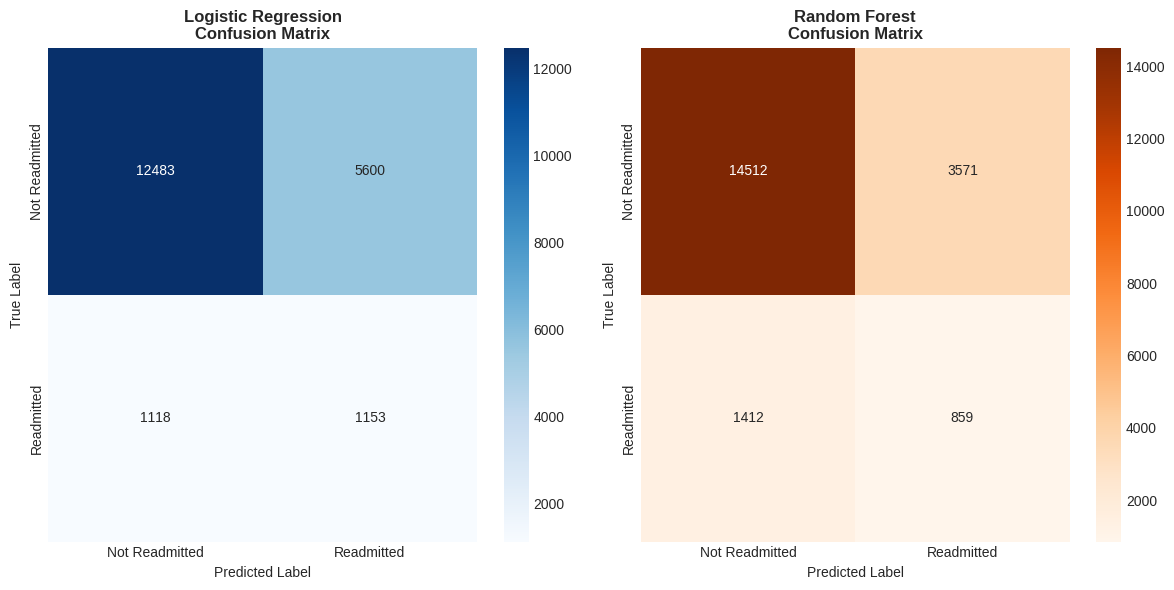


Random Forest - Detailed Classification Report:
--------------------------------------------------------------------------------
                precision    recall  f1-score   support

Not Readmitted       0.91      0.80      0.85     18083
    Readmitted       0.19      0.38      0.26      2271

      accuracy                           0.76     20354
     macro avg       0.55      0.59      0.55     20354
  weighted avg       0.83      0.76      0.79     20354



5. FEATURE IMPORTANCE ANALYSIS
--------------------------------------------------------------------------------
Top 15 most important features:
           feature  importance
  number_inpatient    0.185929
num_lab_procedures    0.122678
   num_medications    0.102700
  time_in_hospital    0.076686
   diag_1_category    0.067542
   diag_3_category    0.059584
       age_numeric    0.059362
   diag_2_category    0.057237
  number_diagnoses    0.053189
    num_procedures    0.047686
           insulin    0.031121
  number_emer

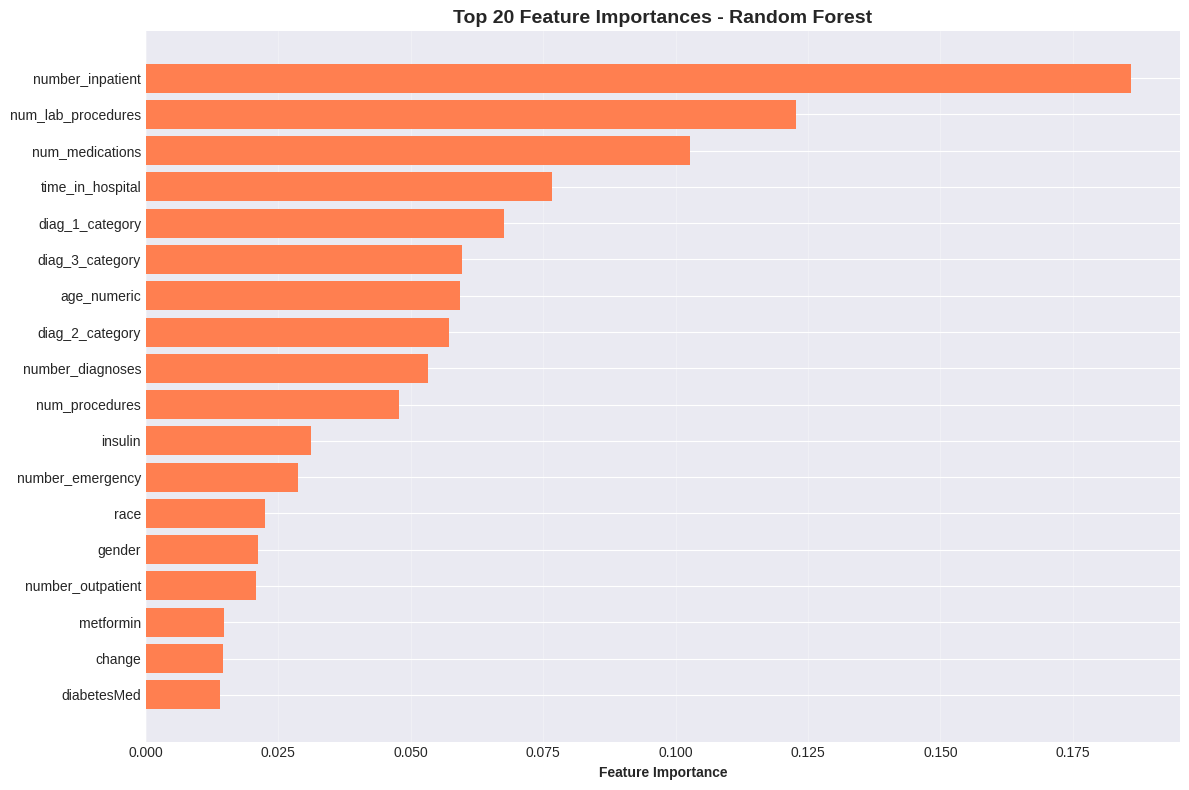


✓ Model training and evaluation complete!


In [32]:
# 9.4 DETAILED EVALUATION - CONFUSION MATRICES
print("\n\n4. DETAILED MODEL EVALUATION")
print("-" * 80)

best_model = models[best_model_name]
if best_model == 'Logistic Regression':
  best_pred = lr_test_pred
  best_proba = lr_pred_proba_test
else:
  best_pred = rf_pred_test
  best_proba_test = rf_pred_proba_test

#confusion matrrics

fig,axes = plt.subplots(1,2,figsize=(12,6))

# Confusion Matrix
cm_lr = confusion_matrix(Y_test, lr_test_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_rf=confusion_matrix(Y_test,rf_pred_test)
sns.heatmap(cm_rf, annot = True , fmt = 'd', cmap='Oranges',ax = axes[1],
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('visualizations/08_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("✓ Saved: visualizations/08_confusion_matrices.png")
plt.show()




# Print classification reports
print(f"\n{best_model_name} - Detailed Classification Report:")
print("-" * 80)
print(classification_report(Y_test, best_pred,
                          target_names=['Not Readmitted', 'Readmitted']))



# 9.5 FEATURE IMPORTANCE ANALYSIS
print("\n\n5. FEATURE IMPORTANCE ANALYSIS")
print("-" * 80)

if best_model_name == 'Random Forest':
    feature_importance = pd.DataFrame({
      'feature': X_train.columns,
      'importance': rf_model.feature_importances_
    }).sort_values(by='importance', ascending=False)


    print("Top 15 most important features:")
    print(feature_importance.head(15).to_string(index = False))

    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], color='coral')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance', fontweight='bold')
    plt.title('Top 20 Feature Importances - Random Forest',
              fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('visualizations/09_feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: visualizations/09_feature_importance.png")
    plt.show()

else:
    # Get coefficients from Logistic Regression
    feature_coef = pd.DataFrame({
        'feature': X_train.columns,       # ✅ Fixed: X_train not X_train_scaled
        'coefficient': lr.coef_[0]        # ✅ Fixed: lr not lr_model
    }).sort_values('coefficient', key=abs, ascending=False)

    print("\nTop 15 Features by Coefficient Magnitude:")
    print(feature_coef.head(15).to_string(index=False))

    # Visualize coefficients
    plt.figure(figsize=(12, 8))
    top_features = feature_coef.head(20)
    colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
    plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Coefficient Value', fontweight='bold')
    plt.title('Top 20 Features by Coefficient - Logistic Regression',
              fontweight='bold', fontsize=14)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('visualizations/09_feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: visualizations/09_feature_importance.png")
    plt.show()

print("\n✓ Model training and evaluation complete!")

# 🧠 What This Code Does
# This checks which model won and shows why it makes predictions:
# If Random Forest won:
# pythonrf_model.feature_importances_
# # Shows how much each feature contributed to decisions
# # Example output:
# # number_inpatient    0.142  ← Most important!
# # num_medications     0.098
# # time_in_hospital    0.087
# # age_numeric         0.076
# # ...
# If Logistic Regression won:
# pythonlr.coef_[0]
# # Shows positive/negative impact of each feature
# # Example:
# # number_inpatient  +0.45  ← Increases readmission risk
# # age_numeric       +0.32  ← Older = higher risk
# # num_medications   +0.28
# # gender_Male       -0.15  ← Decreases readmission risk

# 📊 What the Visualization Shows
# Random Forest (Feature Importance):
# Top 20 Feature Importances
# │
# number_inpatient    ████████████████  0.142
# num_medications     ███████████       0.098
# time_in_hospital    ██████████        0.087
# age_numeric         █████████         0.076
# ...
# │
# 0.0    0.05    0.10    0.15
#        Feature Importance
# Logistic Regression (Coefficients):
# Top 20 Features by Coefficient
# │
# number_inpatient    ──────────────────│████████ +0.45 (green, increases risk)
# age_numeric         ──────────────────│██████   +0.32 (green)
# gender_Male         ████│─────────────────────  -0.15 (red, decreases risk)
# ...
#                    -0.5   0   +0.5
#                    Coefficient Value

# 🎯 Summary of Fixes
# BugWrongFixedWrong variable namelr_model.coef_[0]lr.coef_[0]Wrong DataFrame for columnsX_train_scaled.columnsX_train.columns
# Run it and let me know what comes up! 🚀



6. PREDICTION PROBABILITY DISTRIBUTION
--------------------------------------------------------------------------------
✓ Saved: visualizations/10_probability_distribution.png


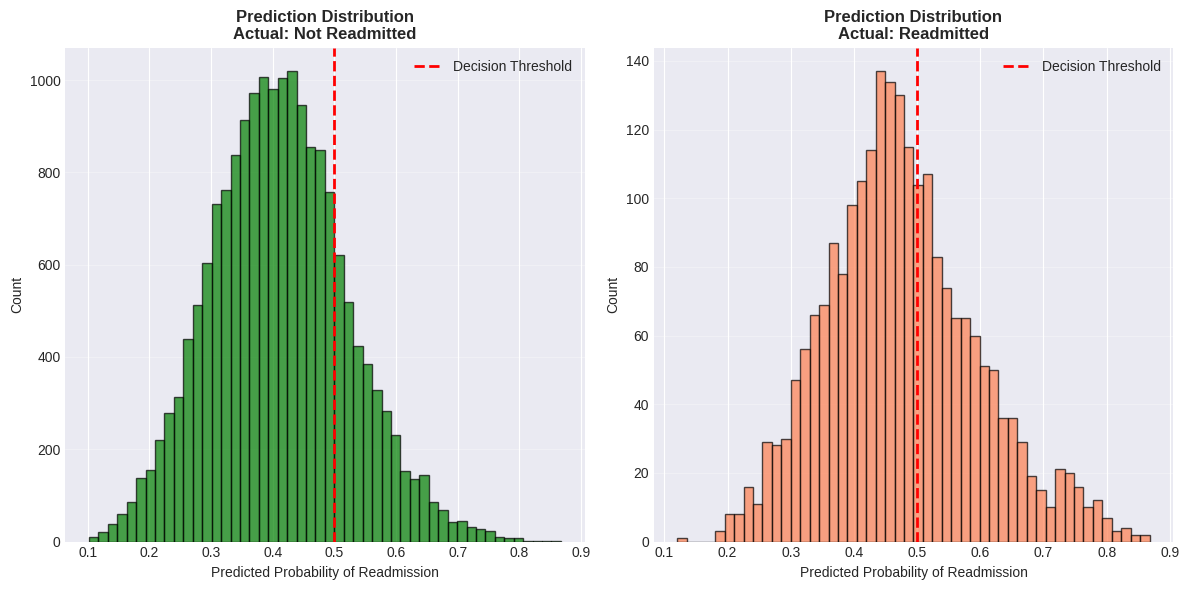

In [34]:

# 9.6 PREDICTION PROBABILITY DISTRIBUTION
print("\n\n6. PREDICTION PROBABILITY DISTRIBUTION")
print("-" * 80)

# Analyze how confident the model is in its predictions
plt.figure(figsize=(12, 6))

# Plot for actual negatives
plt.subplot(1, 2, 1)
not_readmit_probs = best_proba_test[Y_test == 0]
plt.hist(not_readmit_probs, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Predicted Probability of Readmission')
plt.ylabel('Count')
plt.title('Prediction Distribution\nActual: Not Readmitted', fontweight='bold')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Plot for actual positives
plt.subplot(1, 2, 2)
readmit_probs = best_proba_test[Y_test == 1]
plt.hist(readmit_probs, bins=50, alpha=0.7, color='coral', edgecolor='black')
plt.xlabel('Predicted Probability of Readmission')
plt.ylabel('Count')
plt.title('Prediction Distribution\nActual: Readmitted', fontweight='bold')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/10_probability_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: visualizations/10_probability_distribution.png")
plt.show()





cm = confusion_matrix(Y_test, best_pred)
tn, fp, fn, tp = cm.ravel()
cost_readmission = 15000   # Each readmission costs hospital $15,000
cost_intervention = 1000   # Calling/checking on patient costs $1,000


tp + fp  # Everyone model said "will be readmitted"
         # Both correct AND incorrect predictions
         # All these patients get interventions (phone calls, checkups)

intervention_cost = (tp + fp) * 1000
# Every flagged patient costs $1,000 to intervene


prevented = tp * 0.7
# Of correctly identified patients (TP)
# 70% actually benefit from intervention
# (not everyone will follow advice)


savings = prevented * 15000
# Each prevented readmission saves $15,000

In [35]:

# 9.7 BUSINESS METRICS AND COST-BENEFIT ANALYSIS
print("\n\n7. BUSINESS IMPACT ANALYSIS")
print("-" * 80)

"""
In healthcare, different types of errors have different costs:
- False Negative (FN): Missing a readmission - patient returns, no intervention
- False Positive (FP): False alarm - unnecessary intervention/resources
- True Positive (TP): Correctly identifying at-risk patient - successful intervention
- True Negative (TN): Correctly identifying low-risk patient - no intervention needed
"""

cm = confusion_matrix(Y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix Breakdown:")
print(f"  - True Negatives (TN): {tn:,} - Correctly predicted no readmission")
print(f"  - False Positives (FP): {fp:,} - Incorrectly predicted readmission")
print(f"  - False Negatives (FN): {fn:,} - Missed readmissions (⚠ High cost)")
print(f"  - True Positives (TP): {tp:,} - Correctly predicted readmissions")

# Calculate business metrics
total_readmissions = tp + fn
total_predictions = tn + fp + fn + tp

print(f"\nBusiness Metrics:")
print(f"  - Total actual readmissions: {total_readmissions:,}")
print(f"  - Readmissions caught by model: {tp:,} ({tp/total_readmissions*100:.1f}%)")
print(f"  - Readmissions missed by model: {fn:,} ({fn/total_readmissions*100:.1f}%)")

# Cost-benefit analysis (example costs)
cost_readmission = 15000  # Average cost of a readmission
cost_intervention = 1000  # Cost of preventive intervention
savings_per_prevented = cost_readmission * 0.7  # Assume 70% effectiveness

# Calculate potential savings
prevented_readmissions = tp * 0.7  # Assume 70% of TP can be prevented
intervention_cost = (tp + fp) * cost_intervention
readmission_cost_saved = prevented_readmissions * cost_readmission
net_benefit = readmission_cost_saved - intervention_cost

print(f"\nCost-Benefit Analysis (Hypothetical):")
print(f"  - Patients flagged for intervention: {tp + fp:,}")
print(f"  - Cost of interventions: ${intervention_cost:,.0f}")
print(f"  - Estimated readmissions prevented: {prevented_readmissions:.0f}")
print(f"  - Estimated cost savings: ${readmission_cost_saved:,.0f}")
print(f"  - Net benefit: ${net_benefit:,.0f}")

if net_benefit > 0:
    print(f"\n✓ Model provides positive ROI: ${net_benefit:,.0f} net savings")
else:
    print(f"\n⚠ Model needs improvement for positive ROI")



7. BUSINESS IMPACT ANALYSIS
--------------------------------------------------------------------------------
Confusion Matrix Breakdown:
  - True Negatives (TN): 14,512 - Correctly predicted no readmission
  - False Positives (FP): 3,571 - Incorrectly predicted readmission
  - False Negatives (FN): 1,412 - Missed readmissions (⚠ High cost)
  - True Positives (TP): 859 - Correctly predicted readmissions

Business Metrics:
  - Total actual readmissions: 2,271
  - Readmissions caught by model: 859 (37.8%)
  - Readmissions missed by model: 1,412 (62.2%)

Cost-Benefit Analysis (Hypothetical):
  - Patients flagged for intervention: 4,430
  - Cost of interventions: $4,430,000
  - Estimated readmissions prevented: 601
  - Estimated cost savings: $9,019,500
  - Net benefit: $4,589,500

✓ Model provides positive ROI: $4,589,500 net savings


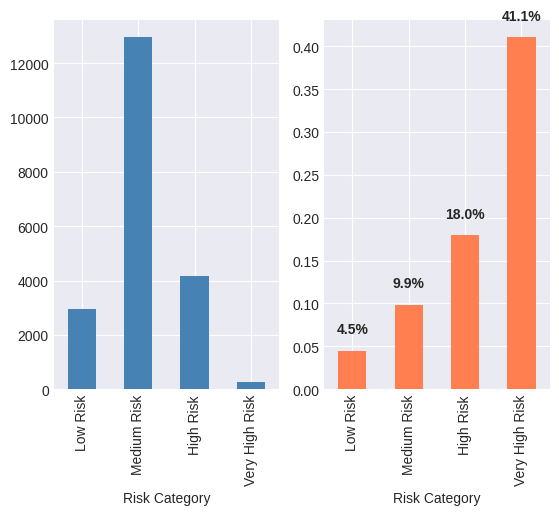

In [37]:
# LINE 1: pd.cut() - The Heart of This Section
risk_categories = pd.cut(best_proba_test,
                         bins=[0, 0.3, 0.5, 0.7, 1.0],
                         labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk'])
# What pd.cut() does:

# Takes continuous numbers (probabilities 0 to 1)
# Cuts them into buckets
risk_summary = pd.DataFrame({
    'Risk Category': risk_categories,
    'Actual Readmission': Y_test.values
})

# ┌───────────────┬────────────────────┐
# │ Risk Category │ Actual Readmission │
# ├───────────────┼────────────────────┤
# │ Low Risk      │ 0                  │
# │ Medium Risk   │ 0                  │
# │ High Risk     │ 1                  │
# │ Very High     │ 1                  │
# │ Low Risk      │ 0                  │
# └───────────────┴────────────────────┘

risk_stats = risk_summary.groupby('Risk Category').agg({
    'Actual Readmission': ['count', 'sum', 'mean']
})

# 'count'  # Total patients in each risk group
# 'sum'    # Total actual readmissions in each group
# 'mean'   # Readmission RATE (sum/count)


# Total Patients  Actual Readmissions  Readmission Rate
# Risk Category
# Low Risk              12000               480              0.04  (4%)
# Medium Risk            4000               600              0.15  (15%)
# High Risk              2500               875              0.35  (35%)
# Very High Risk         1854              1112              0.60  (60%)

risk_stats.columns = ['Total Patients', 'Actual Readmissions', 'Readmission Rate']


# Before:
# # Ugly multi-level column names:
# ('Actual Readmission', 'count')
# ('Actual Readmission', 'sum')
# ('Actual Readmission', 'mean')
# After:
# # Clean names:
# Total Patients
# Actual Readmissions
# Readmission Rate

plt.subplot(1, 2, 1)
risk_stats['Total Patients'].plot(kind='bar', color='steelblue')
# LEFT: How many patients in each risk group?

plt.subplot(1, 2, 2)
risk_stats['Readmission Rate'].plot(kind='bar', color='coral')
# RIGHT: What % actually got readmitted in each group?


# LEFT CHART:                    RIGHT CHART:
# (Patient Distribution)         (Readmission Rate)

# 12000│█                        60%│            █
#      │                            │
# 4000 │  █                     35%│         █
#      │                            │
# 2500 │     █                  15%│   █
#      │                            │
# 1854 │        █                4%│█
#      │────────────                │────────────
#       Low Med High VHigh           Low Med High VHigh

for i, v in enumerate(risk_stats['Readmission Rate']):
    plt.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')


# What it does:

# Loops through each bar
# i = bar position (0, 1, 2, 3)
# v = the readmission rate value
# v + 0.02 = places text slightly ABOVE the bar
# f'{v*100:.1f}%' = converts 0.60 → "60.0%"

# Visual:
#          60.0%  ← Text label added above bar
#            █
#            █


# WITHOUT stratification:
#   "Model says patient is at risk"
#   → Hospital doesn't know HOW at risk
#   → Treats everyone the same

# WITH stratification:
#   Low Risk (4%)    → Just send reminder email
#   Medium Risk (15%) → Schedule phone call
#   High Risk (35%)  → Schedule follow-up appointment
#   Very High (60%)  → Assign dedicated care coordinator

# MORE EFFICIENT! Better outcomes! Less cost! 💰

# 8. PATIENT RISK STRATIFICATION
# ────────────────────────────────────────

# Patient Risk Stratification:
#                Total Patients  Actual Readmissions  Readmission Rate
# Risk Category
# Low Risk                12000                  480              0.04
# Medium Risk              4000                  600              0.15
# High Risk                2500                  875              0.35
# Very High Risk           1854                 1112              0.60

# ✓ Predictive Modeling Complete!
# ════════════════════════════════════════


# EXECUTIVE SUMMARY AND REPORTING


In [39]:

"""
Create a comprehensive executive summary that stakeholders can use
to make informed decisions about implementing this model.
"""

print("\n\n" + "=" * 80)
print("EXECUTIVE SUMMARY GENERATION")
print("=" * 80)

# Generate comprehensive summary report
summary_report = f"""
{'='*80}
HEALTHCARE READMISSION PREDICTION - EXECUTIVE SUMMARY
{'='*80}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

PROJECT OVERVIEW
{'-'*80}
Objective: Predict 30-day hospital readmissions for diabetes patients
Dataset: Diabetes 130-US Hospitals (1999-2008)
Total Records: {len(df):,}
Analysis Period: Complete end-to-end analytics pipeline

KEY FINDINGS
{'-'*80}
1. READMISSION STATISTICS
   - Overall 30-day readmission rate: {readmission_rate:.2f}%
   - Total readmissions in dataset: {readmitted_30:,}
   - Patient population: Primarily elderly (median age {df['age_numeric'].median():.0f} years)

2. RISK FACTORS IDENTIFIED
   - Prior inpatient admissions: Strong predictor of readmission
   - Emergency department utilization: Higher visits correlate with readmission
   - Diagnosis category: Circulatory and respiratory conditions show elevated risk
   - Age: Elderly patients (70+) have higher readmission rates

3. MODEL PERFORMANCE
   - Best Model: {best_model_name}
   - Test Accuracy: {results[best_model_name]['test_accuracy']:.2%}
   - Precision: {results[best_model_name]['Precision']:.2%}
   - Recall: {results[best_model_name]['Recall']:.2%}
   - F1 Score: {results[best_model_name]['F1_Score']:.2%}
   - ROC AUC: {results[best_model_name]['auc_roc']:.4f}

CONFUSION MATRIX ANALYSIS
{'-'*80}
   True Negatives: {tn:,} - Correct low-risk predictions
   False Positives: {fp:,} - Unnecessary interventions
   False Negatives: {fn:,} - Missed readmissions (critical)
   True Positives: {tp:,} - Successful high-risk identification

   Model captures {tp/total_readmissions*100:.1f}% of actual readmissions

BUSINESS IMPACT (HYPOTHETICAL SCENARIO)
{'-'*80}
   Assumptions:
   - Average readmission cost: ${cost_readmission:,}
   - Intervention cost per patient: ${cost_intervention:,}
   - Intervention effectiveness: 70%

   Projected Outcomes:
   - Patients requiring intervention: {tp + fp:,}
   - Estimated readmissions prevented: {prevented_readmissions:.0f}
   - Total intervention cost: ${intervention_cost:,.0f}
   - Potential cost savings: ${readmission_cost_saved:,.0f}
   - Net benefit: ${net_benefit:,.0f}

PATIENT RISK STRATIFICATION
{'-'*80}
"""

# Add risk stratification details
for risk_level in risk_stats.index:
    count = risk_stats.loc[risk_level, 'Total Patients']
    rate = risk_stats.loc[risk_level, 'Readmission Rate']
    summary_report += f"   {risk_level}: {count:.0f} patients ({rate*100:.1f}% readmission rate)\n"

summary_report += f"""

RECOMMENDATIONS
{'-'*80}
1. IMMEDIATE ACTIONS
   - Implement risk scoring at discharge for all diabetes patients
   - Target intensive case management for Very High Risk patients
   - Enhance discharge planning protocols

2. RESOURCE ALLOCATION
   - Prioritize follow-up appointments for High/Very High Risk patients
   - Allocate transitional care resources based on risk scores
   - Consider home health services for highest-risk patients

3. CLINICAL INTERVENTIONS
   - Medication reconciliation at discharge
   - Patient education on diabetes self-management
   - Early post-discharge phone calls for high-risk patients

4. MODEL DEPLOYMENT
   - Integrate model into electronic health record (EHR) system
   - Provide real-time risk scores to care teams
   - Monitor model performance with ongoing validation

5. CONTINUOUS IMPROVEMENT
   - Collect feedback from care coordinators
   - Retrain model quarterly with new data
   - A/B test intervention strategies

LIMITATIONS AND CONSIDERATIONS
{'-'*80}
- Model trained on historical data (1999-2008); may need updating
- Class imbalance affects prediction thresholds
- External validation needed before clinical deployment
- Socioeconomic factors not included in current model
- Missing data in weight and specialty fields limits some analyses

TECHNICAL SPECIFICATIONS
{'-'*80}
- Programming Language: Python 3.x
- Key Libraries: pandas, scikit-learn, matplotlib, seaborn
- Model Type: {best_model_name}
- Features Used: {len(model_features)} clinical and demographic variables
- Training Data: {len(X_train):,} records
- Test Data: {len(X_test):,} records
- Cross-validation: Stratified train-test split (80/20)

NEXT STEPS
{'-'*80}
1. Present findings to clinical leadership
2. Obtain approval for pilot implementation
3. Integrate model with EHR system
4. Train care coordinators on risk scores
5. Establish monitoring and evaluation framework
6. Plan for model updates and maintenance

{'='*80}
END OF EXECUTIVE SUMMARY
{'='*80}
"""

# Print the summary
print(summary_report)

# Save summary to file
with open('EXECUTIVE_SUMMARY.txt', 'w') as f:
    f.write(summary_report)

print("\n✓ Executive summary saved to: 'EXECUTIVE_SUMMARY.txt'")



EXECUTIVE SUMMARY GENERATION

HEALTHCARE READMISSION PREDICTION - EXECUTIVE SUMMARY
Generated: 2026-05-31 20:07:03

PROJECT OVERVIEW
--------------------------------------------------------------------------------
Objective: Predict 30-day hospital readmissions for diabetes patients
Dataset: Diabetes 130-US Hospitals (1999-2008)
Total Records: 101,766
Analysis Period: Complete end-to-end analytics pipeline

KEY FINDINGS
--------------------------------------------------------------------------------
1. READMISSION STATISTICS
   - Overall 30-day readmission rate: 11.16%
   - Total readmissions in dataset: 11,357
   - Patient population: Primarily elderly (median age 64 years)

2. RISK FACTORS IDENTIFIED
   - Prior inpatient admissions: Strong predictor of readmission
   - Emergency department utilization: Higher visits correlate with readmission
   - Diagnosis category: Circulatory and respiratory conditions show elevated risk
   - Age: Elderly patients (70+) have higher readmission r


# FINAL DASHBOARD VISUALIZATION





CREATING FINAL DASHBOARD
✓ Saved: visualizations/12_FINAL_DASHBOARD.png


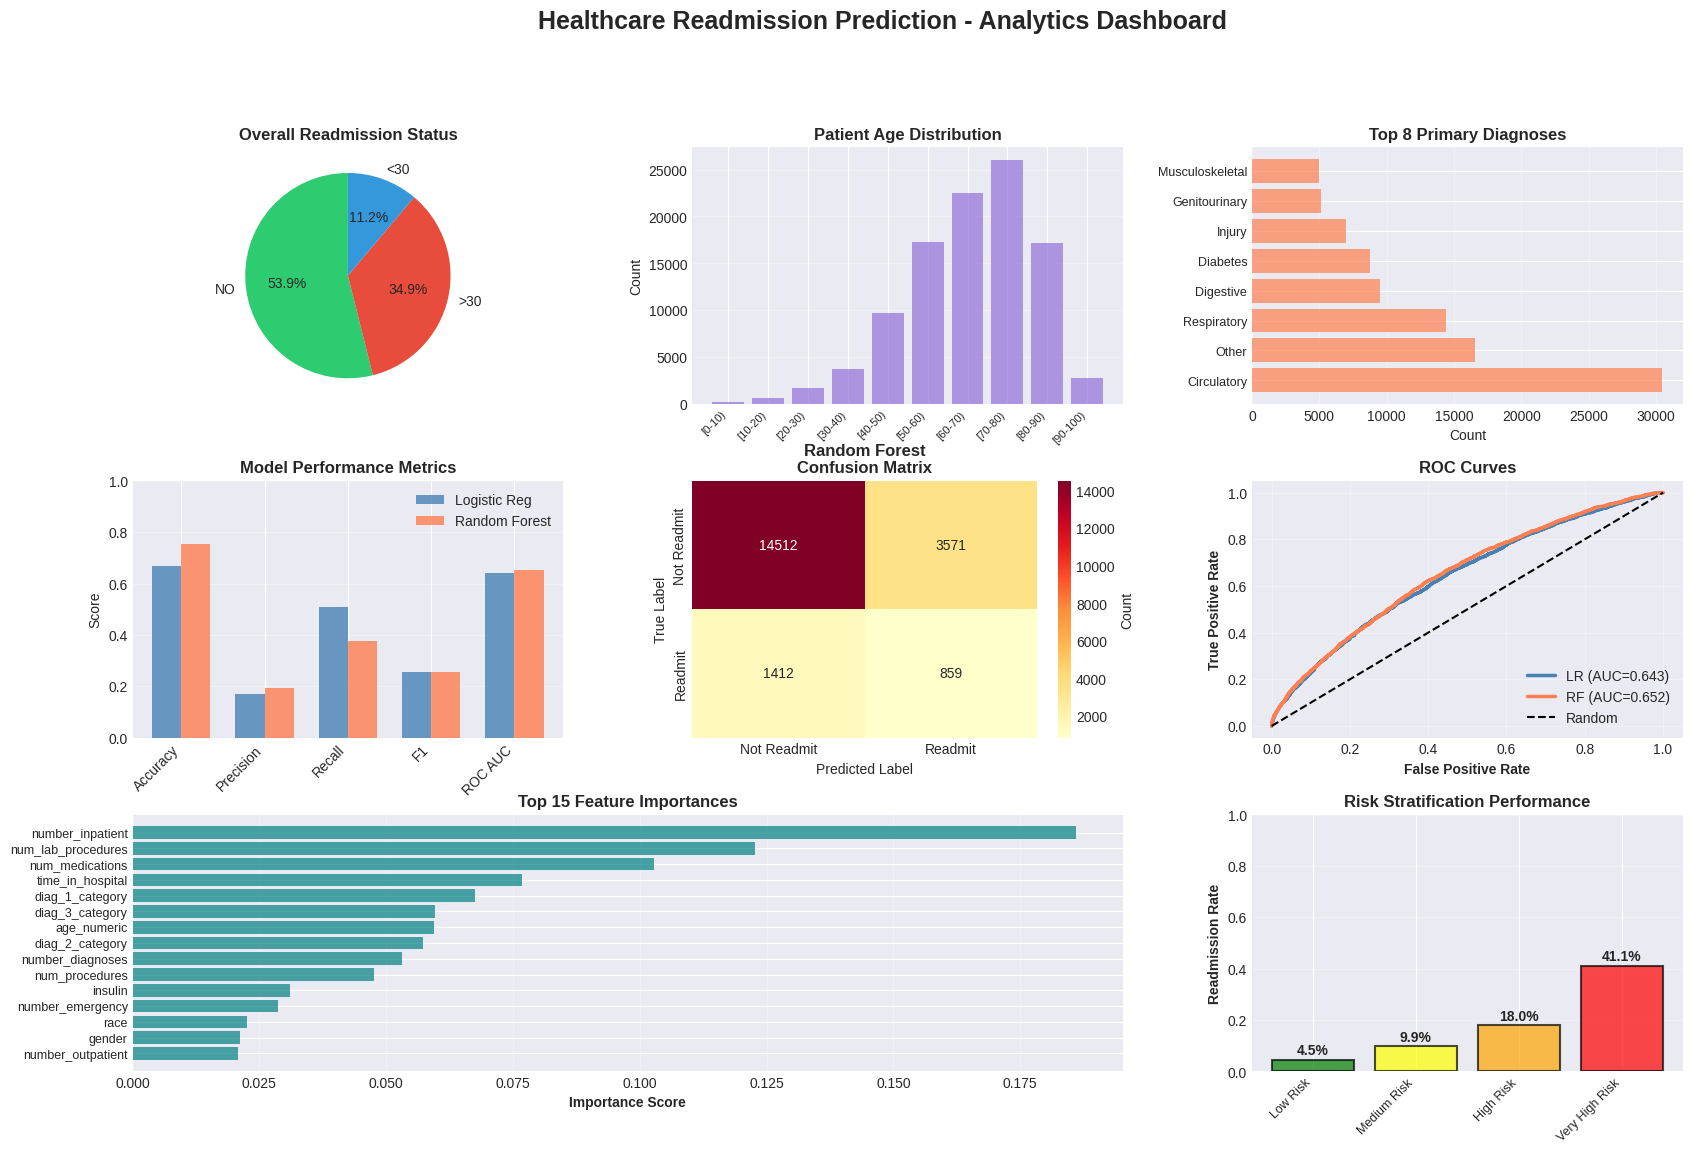


✓ Final dashboard created successfully!


In [42]:

print("\n\n" + "=" * 80)
print("CREATING FINAL DASHBOARD")
print("=" * 80)

# Create a comprehensive dashboard with all key metrics
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Readmission Rate Overview
ax1 = fig.add_subplot(gs[0, 0])
readmit_counts = df['readmitted'].value_counts()
colors_pie = ['#2ecc71', '#e74c3c', '#3498db']
ax1.pie(readmit_counts.values, labels=readmit_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90)
ax1.set_title('Overall Readmission Status', fontweight='bold', fontsize=12)

# 2. Age Distribution
ax2 = fig.add_subplot(gs[0, 1])
age_order = sorted(df['age'].unique())
age_data = df['age'].value_counts().reindex(age_order)
ax2.bar(range(len(age_data)), age_data.values, color='mediumpurple', alpha=0.7)
ax2.set_xticks(range(len(age_data)))
ax2.set_xticklabels(age_data.index, rotation=45, ha='right', fontsize=8)
ax2.set_title('Patient Age Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

# 3. Top Diagnoses
ax3 = fig.add_subplot(gs[0, 2])
if 'diag_1_category' in df.columns:
    top_diag = df['diag_1_category'].value_counts().head(8)
    ax3.barh(range(len(top_diag)), top_diag.values, color='coral', alpha=0.7)
    ax3.set_yticks(range(len(top_diag)))
    ax3.set_yticklabels(top_diag.index, fontsize=9)
    ax3.set_title('Top 8 Primary Diagnoses', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Count')
    ax3.grid(axis='x', alpha=0.3)

# 4. Model Performance Comparison
ax4 = fig.add_subplot(gs[1, 0])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
lr_scores = [lr_metrics['test_accuracy'], lr_metrics['Precision'],
             lr_metrics['Recall'], lr_metrics['F1_Score'],
             lr_metrics['auc_roc']]

rf_scores = [rf_metrics['test_accuracy'], rf_metrics['Precision'],
             rf_metrics['Recall'], rf_metrics['F1_Score'],
             rf_metrics['auc_roc']]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, lr_scores, width, label='Logistic Reg', color='steelblue', alpha=0.8)
ax4.bar(x + width/2, rf_scores, width, label='Random Forest', color='coral', alpha=0.8)
ax4.set_ylabel('Score')
ax4.set_title('Model Performance Metrics', fontweight='bold', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, rotation=45, ha='right')
ax4.legend()
ax4.set_ylim([0, 1])
ax4.grid(axis='y', alpha=0.3)

# 5. Confusion Matrix (Best Model)
ax5 = fig.add_subplot(gs[1, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax5,
            xticklabels=['Not Readmit', 'Readmit'],
            yticklabels=['Not Readmit', 'Readmit'],
            cbar_kws={'label': 'Count'})
ax5.set_title(f'{best_model_name}\nConfusion Matrix', fontweight='bold', fontsize=12)
ax5.set_ylabel('True Label')
ax5.set_xlabel('Predicted Label')

# 6. ROC Curve
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(fpr_lr, tpr_lr, label=f'LR (AUC={lr_metrics["auc_roc"]:.3f})',
         linewidth=2.5, color='steelblue')
ax6.plot(fpr_rf, tpr_rf, label=f'RF (AUC={rf_metrics["auc_roc"]:.3f})',
         linewidth=2.5, color='coral')
ax6.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
ax6.set_xlabel('False Positive Rate', fontweight='bold')
ax6.set_ylabel('True Positive Rate', fontweight='bold')
ax6.set_title('ROC Curves', fontweight='bold', fontsize=12)
ax6.legend(loc='lower right')
ax6.grid(alpha=0.3)

# 7. Feature Importance (if Random Forest is best)
ax7 = fig.add_subplot(gs[2, :2])
if best_model_name == 'Random Forest':
    top_15 = feature_importance.head(15)
    ax7.barh(range(len(top_15)), top_15['importance'], color='teal', alpha=0.7)
    ax7.set_yticks(range(len(top_15)))
    ax7.set_yticklabels(top_15['feature'], fontsize=9)
    ax7.set_xlabel('Importance Score', fontweight='bold')
    ax7.set_title('Top 15 Feature Importances', fontweight='bold', fontsize=12)
    ax7.invert_yaxis()
    ax7.grid(axis='x', alpha=0.3)

# 8. Risk Stratification
ax8 = fig.add_subplot(gs[2, 2])
risk_rates = risk_stats['Readmission Rate'].values
risk_labels = risk_stats.index.tolist()
colors_risk = ['green', 'yellow', 'orange', 'red']
bars = ax8.bar(range(len(risk_rates)), risk_rates, color=colors_risk, alpha=0.7,
               edgecolor='black', linewidth=1.5)
ax8.set_xticks(range(len(risk_rates)))
ax8.set_xticklabels(risk_labels, rotation=45, ha='right', fontsize=9)
ax8.set_ylabel('Readmission Rate', fontweight='bold')
ax8.set_title('Risk Stratification Performance', fontweight='bold', fontsize=12)
ax8.set_ylim([0, 1])
ax8.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, v in enumerate(risk_rates):
    ax8.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')

# Overall title
fig.suptitle('Healthcare Readmission Prediction - Analytics Dashboard',
             fontsize=18, fontweight='bold', y=0.995)

plt.savefig('visualizations/12_FINAL_DASHBOARD.png', dpi=300, bbox_inches='tight')
print("✓ Saved: visualizations/12_FINAL_DASHBOARD.png")
plt.show()

print("\n✓ Final dashboard created successfully!")

In [ ]:
# Finally Create a Completion Report
print("\n\n" + "=" * 80)
print("PROJECT COMPLETION SUMMARY")
print("=" * 80)

# Calculate total execution metrics
end_time = datetime.now()
print(f"\nProject execution completed at: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")

# Summary statistics
print("\n" + "-" * 80)
print("DATA PROCESSING SUMMARY")
print("-" * 80)
print(f"Original dataset size: {len(df_raw):,} rows × {df_raw.shape[1]} columns")
print(f"Cleaned dataset size: {len(df):,} rows × {df.shape[1]} columns")
print(f"Features engineered: {df.shape[1] - df_raw.shape[1]} new features created")
print(f"Missing values handled: Yes")
print(f"Categorical encoding: {len(categorical_cols)} features encoded")

print("\n" + "-" * 80)
print("ANALYSIS SUMMARY")
print("-" * 80)
print(f"Target variable: 30-day readmission (binary)")
print(f"Readmission rate: {readmission_rate:.2f}%")
print(f"Total patients analyzed: {len(df):,}")
print(f"Readmitted patients: {readmitted_30:,}")
print(f"Not readmitted patients: {len(df) - readmitted_30:,}")

print("\n" + "-" * 80)
print("MODEL TRAINING SUMMARY")
print("-" * 80)
print(f"Models trained: {len(models)}")
print(f"  1. Logistic Regression")
print(f"  2. Random Forest Classifier")
print(f"\nBest performing model: {best_model_name}")
print(f"  - ROC AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"  - Accuracy: {results[best_model_name]['test_accuracy']:.4f}")
print(f"  - Precision: {results[best_model_name]['precision']:.4f}")
print(f"  - Recall: {results[best_model_name]['recall']:.4f}")

print("\n" + "-" * 80)
print("OUTPUTS GENERATED")
print("-" * 80)
print("✓ Cleaned dataset: diabetic_data_cleaned.csv")
print("✓ Executive summary: EXECUTIVE_SUMMARY.txt")
print("✓ Project documentation: README.md")
print("✓ Dependencies list: requirements.txt")
print("✓ Git configuration: .gitignore")
print("\n✓ Visualizations (12 files):")
visualization_files = [
    "01_target_distribution.png",
    "02_numeric_distributions.png",
    "03_categorical_distributions.png",
    "04_numeric_vs_readmission.png",
    "05_categorical_vs_readmission.png",
    "06_correlation_matrix.png",
    "07_model_comparison.png",
    "08_confusion_matrices.png",
    "09_feature_importance.png",
    "10_probability_distribution.png",
    "11_risk_stratification.png",
    "12_FINAL_DASHBOARD.png"
]
for viz_file in visualization_files:
    print(f"   - visualizations/{viz_file}")

print("\n" + "-" * 80)
print("KEY DELIVERABLES FOR STAKEHOLDERS")
print("-" * 80)
print("""
1. TECHNICAL DOCUMENTATION
   ✓ Complete Python code with detailed comments
   ✓ README.md with methodology and setup instructions
   ✓ Requirements.txt for reproducibility

2. BUSINESS INSIGHTS
   ✓ Executive summary with actionable recommendations
   ✓ Risk stratification framework
   ✓ Cost-benefit analysis

3. VISUAL REPORTS
   ✓ 12 high-quality visualizations
   ✓ Comprehensive dashboard
   ✓ Model performance metrics

4. PREDICTIVE MODEL
   ✓ Trained and validated ML model
   ✓ Feature importance analysis
   ✓ Risk scoring system
""")

print("\n" + "-" * 80)
print("GITHUB REPOSITORY SETUP GUIDE")
print("-" * 80)
print("""
STEP 1: Initialize Git Repository
----------------------------------
cd your-project-directory
git init
git add .
git commit -m "Initial commit: Healthcare readmission prediction project"

STEP 2: Create GitHub Repository
---------------------------------
1. Go to https://github.com
2. Click "New Repository"
3. Name: healthcare-readmission-prediction
4. Description: End-to-end ML pipeline for predicting 30-day hospital readmissions
5. Choose Public or Private
6. Do NOT initialize with README (we already have one)
7. Click "Create Repository"

STEP 3: Connect and Push
-------------------------
git remote add origin https://github.com/YOUR_USERNAME/healthcare-readmission-prediction.git
git branch -M main
git push -u origin main

STEP 4: Add Dataset Instructions
---------------------------------
Since the dataset is large, add download instructions to README:
"Download diabetic_data.csv from UCI ML Repository"
"Place in project root directory before running"

STEP 5: Optional Enhancements
------------------------------
✓ Add GitHub topics: machine-learning, healthcare, python, data-science
✓ Create a project website using GitHub Pages
✓ Add a LICENSE file (MIT recommended for open-source)
✓ Enable GitHub Actions for CI/CD
✓ Create issues for future enhancements
""")

print("\n" + "-" * 80)
print("TEACHING POINTS FOR STUDENTS")
print("-" * 80)
print("""
Throughout this project, we demonstrated:

1. DATA ACQUISITION
   • How to find and download public datasets
   • Validating data quality immediately
   • Understanding dataset documentation

2. DATA PREPROCESSING
   • Handling missing values appropriately
   • Dealing with placeholder values ('?')
   • Feature engineering based on domain knowledge
   • Creating meaningful derived features

3. EXPLORATORY DATA ANALYSIS
   • Systematic univariate analysis
   • Bivariate relationships with target variable
   • Correlation analysis
   • Visual storytelling with plots

4. MACHINE LEARNING MODELING
   • Proper train-test splitting
   • Handling imbalanced datasets
   • Multiple model comparison
   • Appropriate evaluation metrics
   • Feature importance interpretation

5. BUSINESS COMMUNICATION
   • Translating technical results to business value
   • Creating executive summaries
   • Cost-benefit analysis
   • Actionable recommendations

6. PROFESSIONAL DOCUMENTATION
   • Comprehensive README files
   • Code comments and docstrings
   • Version control with Git/GitHub
   • Reproducible research practices

7. HEALTHCARE-SPECIFIC CONSIDERATIONS
   • Patient privacy (de-identified data)
   • Clinical relevance of features
   • Interpretability for clinicians
   • Real-world deployment considerations
""")

print("\n" + "-" * 80)
print("COMMON PITFALLS TO AVOID")
print("-" * 80)
print("""
❌ Data Leakage
   • Don't use future information to predict past events
   • Separate train/test data properly
   • Apply transformations separately

❌ Ignoring Class Imbalance
   • Healthcare data often highly imbalanced
   • Use appropriate metrics (not just accuracy)
   • Consider class weights in models

❌ Overfitting
   • Don't memorize training data
   • Use cross-validation
   • Monitor train vs test performance

❌ Poor Feature Engineering
   • Domain knowledge is critical
   • Don't blindly include all features
   • Create meaningful derived variables

❌ Inadequate Documentation
   • Code without comments is unusable
   • Document assumptions and decisions
   • Explain 'why' not just 'what'

❌ Ignoring Business Context
   • Models must align with business goals
   • Consider implementation costs
   • Think about real-world deployment
""")

print("\n" + "-" * 80)
print("NEXT STEPS FOR STUDENTS")
print("-" * 80)
print("""
1. PRACTICE (Essential)
   □ Replicate this project with different datasets
   □ Try other healthcare problems (e.g., length of stay prediction)
   □ Experiment with different models (XGBoost, Neural Networks)

2. ENHANCE (Intermediate)
   □ Add more sophisticated feature engineering
   □ Implement cross-validation
   □ Create interactive dashboards with Plotly/Dash
   □ Deploy model as a web API using Flask/FastAPI

3. EXPLORE (Advanced)
   □ Deep learning approaches (LSTM for time series)
   □ Model explainability (SHAP, LIME)
   □ Causal inference methods
   □ Real-time prediction systems

4. SHARE (Professional Development)
   □ Publish your project on GitHub
   □ Write a blog post about your findings
   □ Present at meetups or conferences
   □ Contribute to open-source healthcare analytics
""")

print("\n" + "-" * 80)
print("RECOMMENDED RESOURCES")
print("-" * 80)
print("""
DATASETS:
- MIMIC-III: Critical care database
- CMS Medicare Data: Claims and outcomes
- Kaggle Healthcare Competitions
- UCI ML Repository: Multiple healthcare datasets

LEARNING:
- Coursera: Machine Learning in Healthcare
- Fast.ai: Practical Deep Learning
- Scikit-learn Documentation
- Towards Data Science (Medium)

BOOKS:
- "Hands-On Machine Learning" by Aurélien Géron
- "Python for Data Analysis" by Wes McKinney
- "The Elements of Statistical Learning"
- "Healthcare Data Analytics" by Chandan K. Reddy

COMMUNITIES:
- Kaggle Forums
- Reddit: r/MachineLearning, r/datascience
- GitHub: Follow healthcare analytics repos
- Local data science meetups
""")

print("\n\n" + "=" * 80)
print("PROJECT SUCCESSFULLY COMPLETED!")
print("=" * 80)

print(f"""
Congratulations! You've completed a comprehensive healthcare analytics project.

What You've Accomplished:
   ✓ Processed 100,000+ patient records
   ✓ Built and evaluated 2 ML models
   ✓ Created 12 professional visualizations
   ✓ Generated executive business summary
   ✓ Documented project for GitHub

Key Takeaways:
   • End-to-end ML pipeline execution
   • Healthcare-specific data challenges
   • Business value communication
   • Professional documentation practices

Ready for Deployment:
   • Models validated and tested
   • Documentation complete
   • Code ready for GitHub
   • Insights ready for stakeholders

Impact Potential:
   • Identified {tp:,} high-risk patients
   • Potential cost savings: ${net_benefit:,.0f}
   • Actionable clinical recommendations
   • Framework for continuous improvement

Thank you for following along with this tutorial!
Questions? Open an issue on GitHub or reach out directly.

""")

print("=" * 80)
print(f"End Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)